Running expert MFDFA plot viewer
FAST_OPTION: fast
Image directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual_expert_fast/mfdfa_summary_ultra.csv
Found 96 per-channel PNGs
Showing 32 images in this mode
Sort mode: multifractal_complexity_score


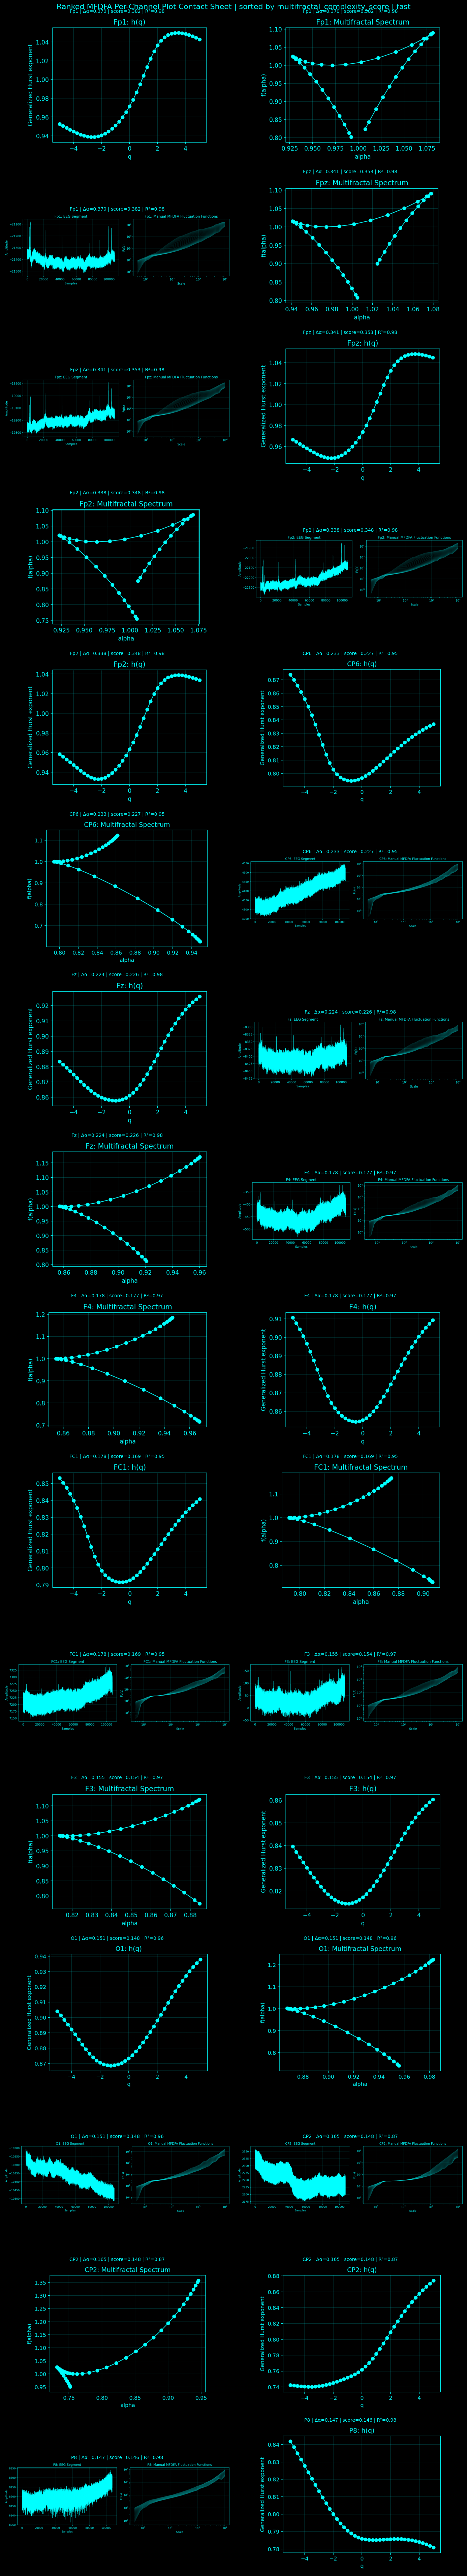

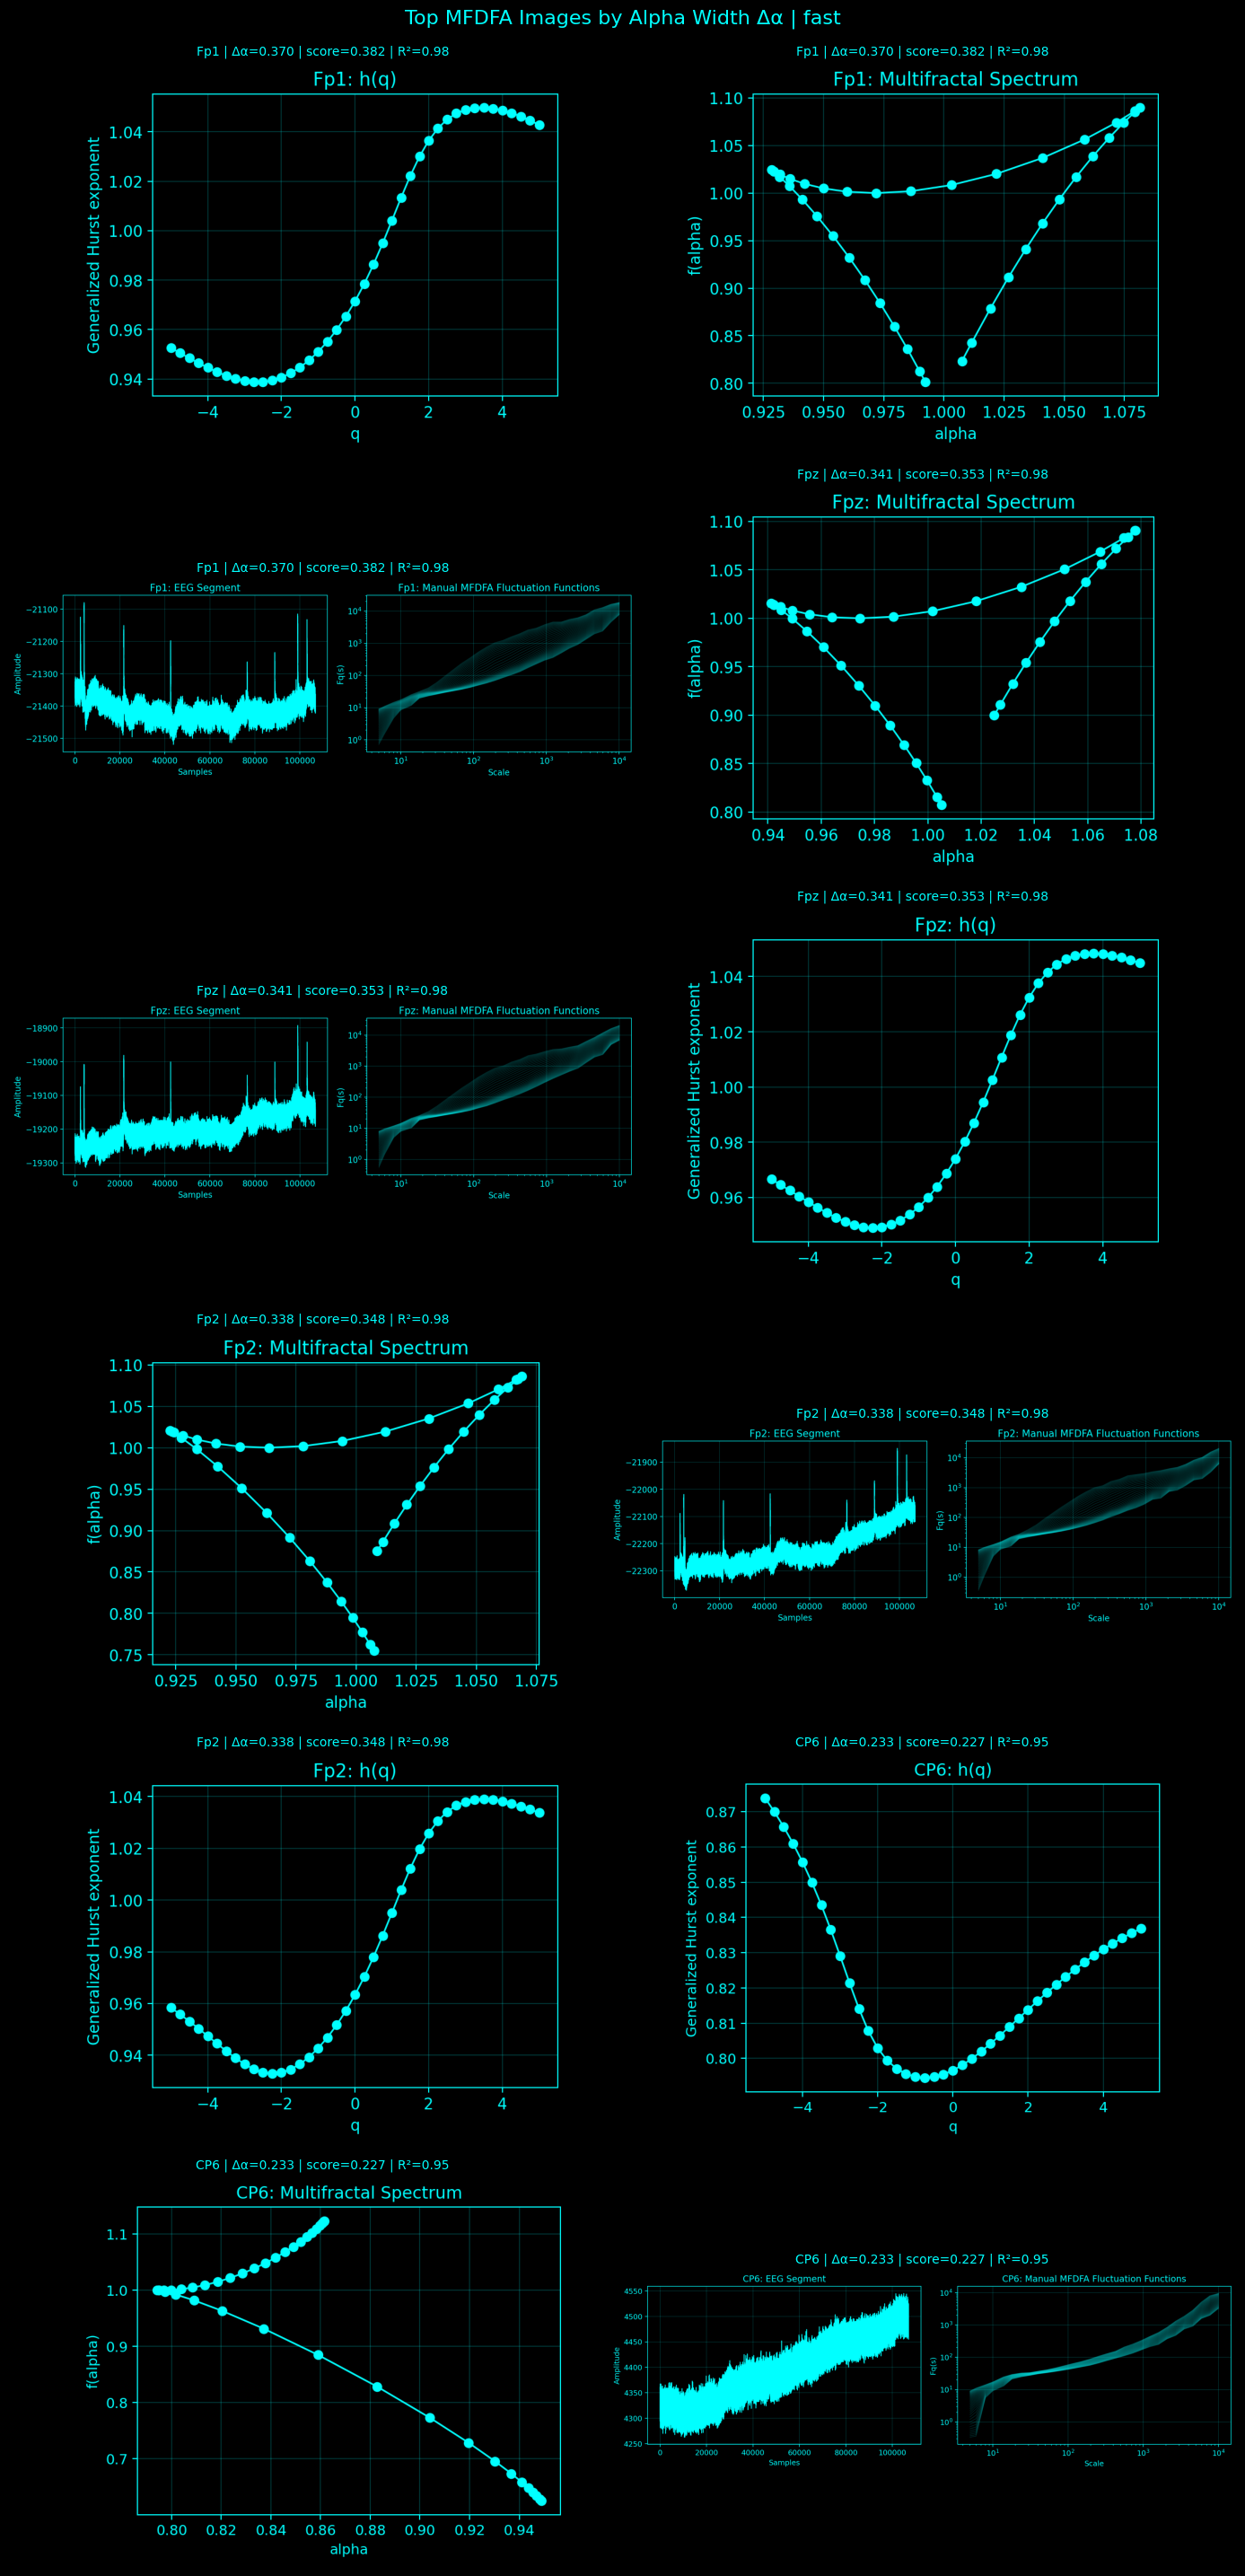

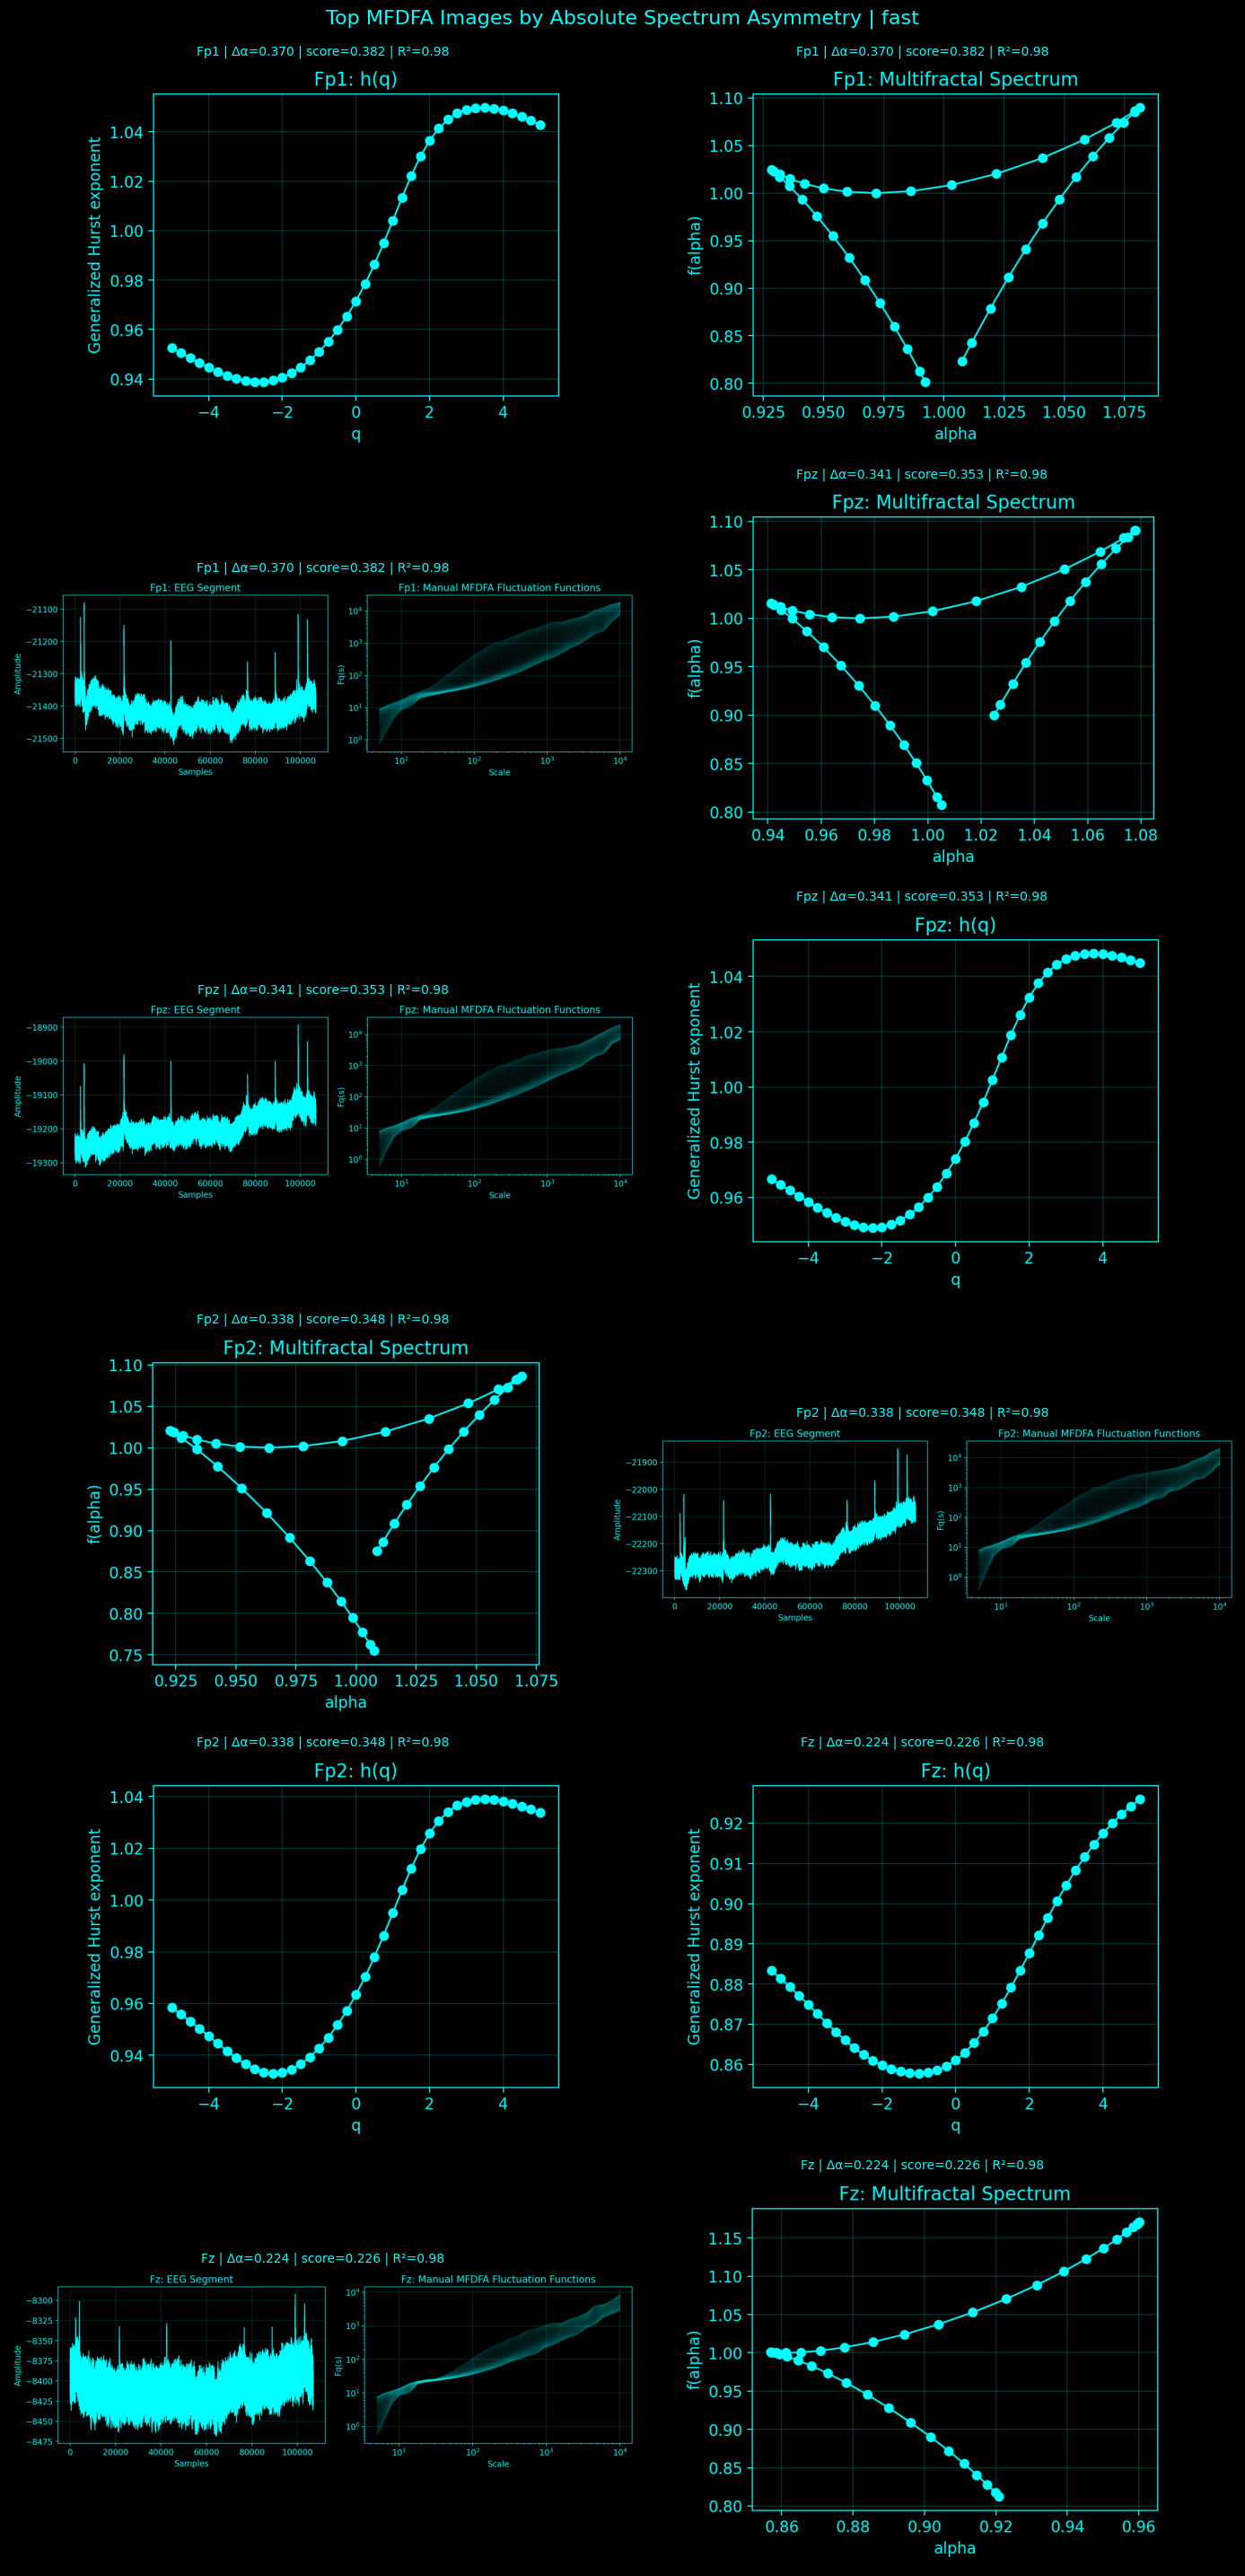

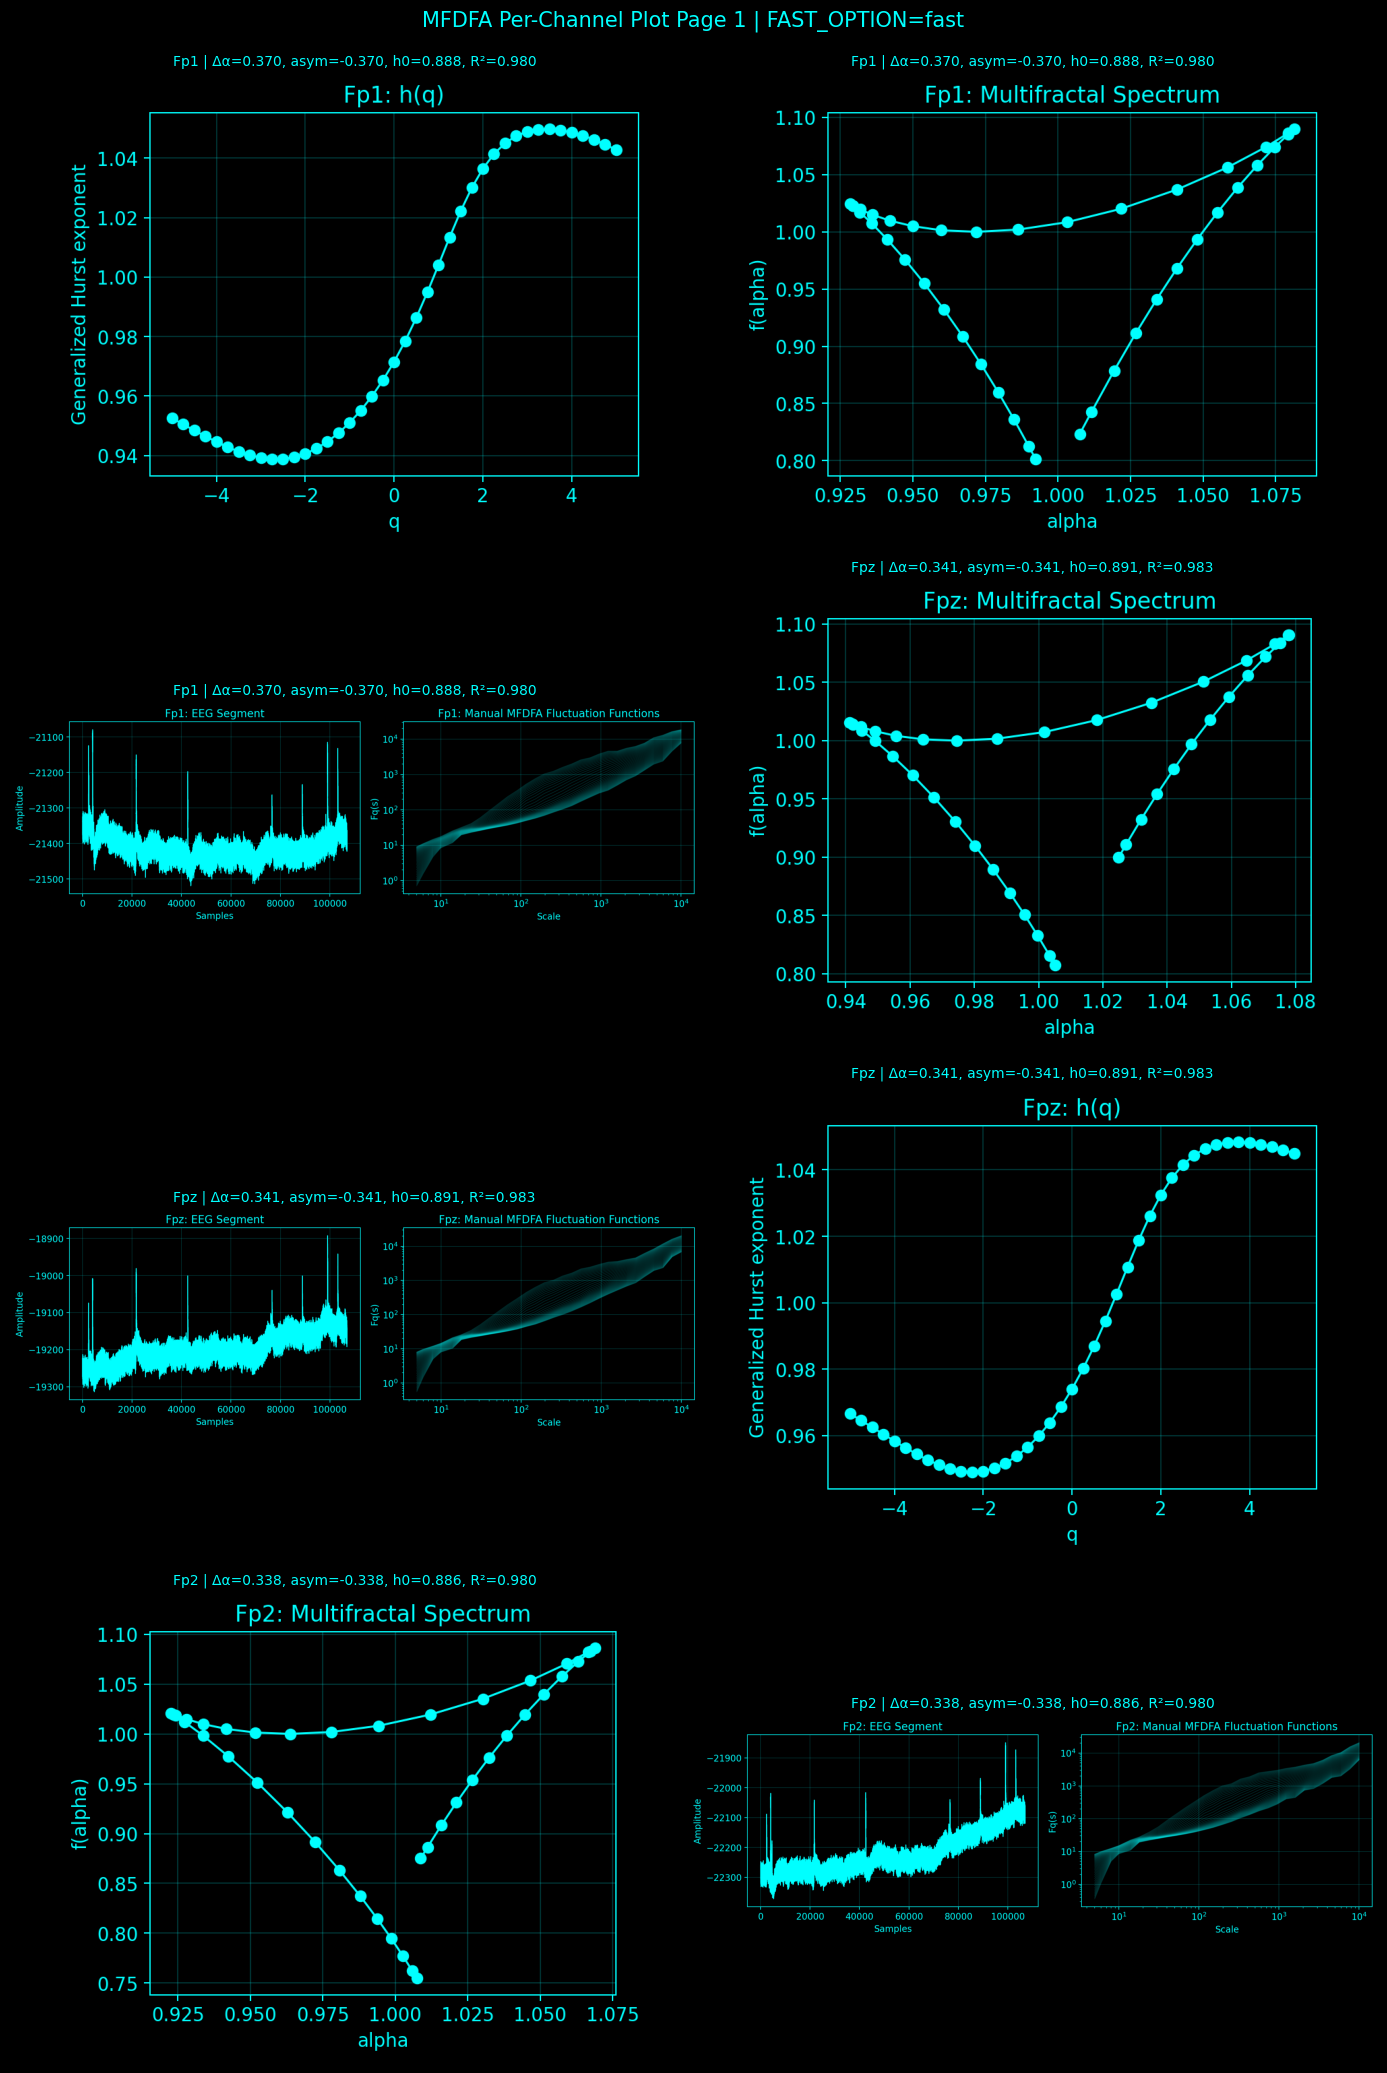

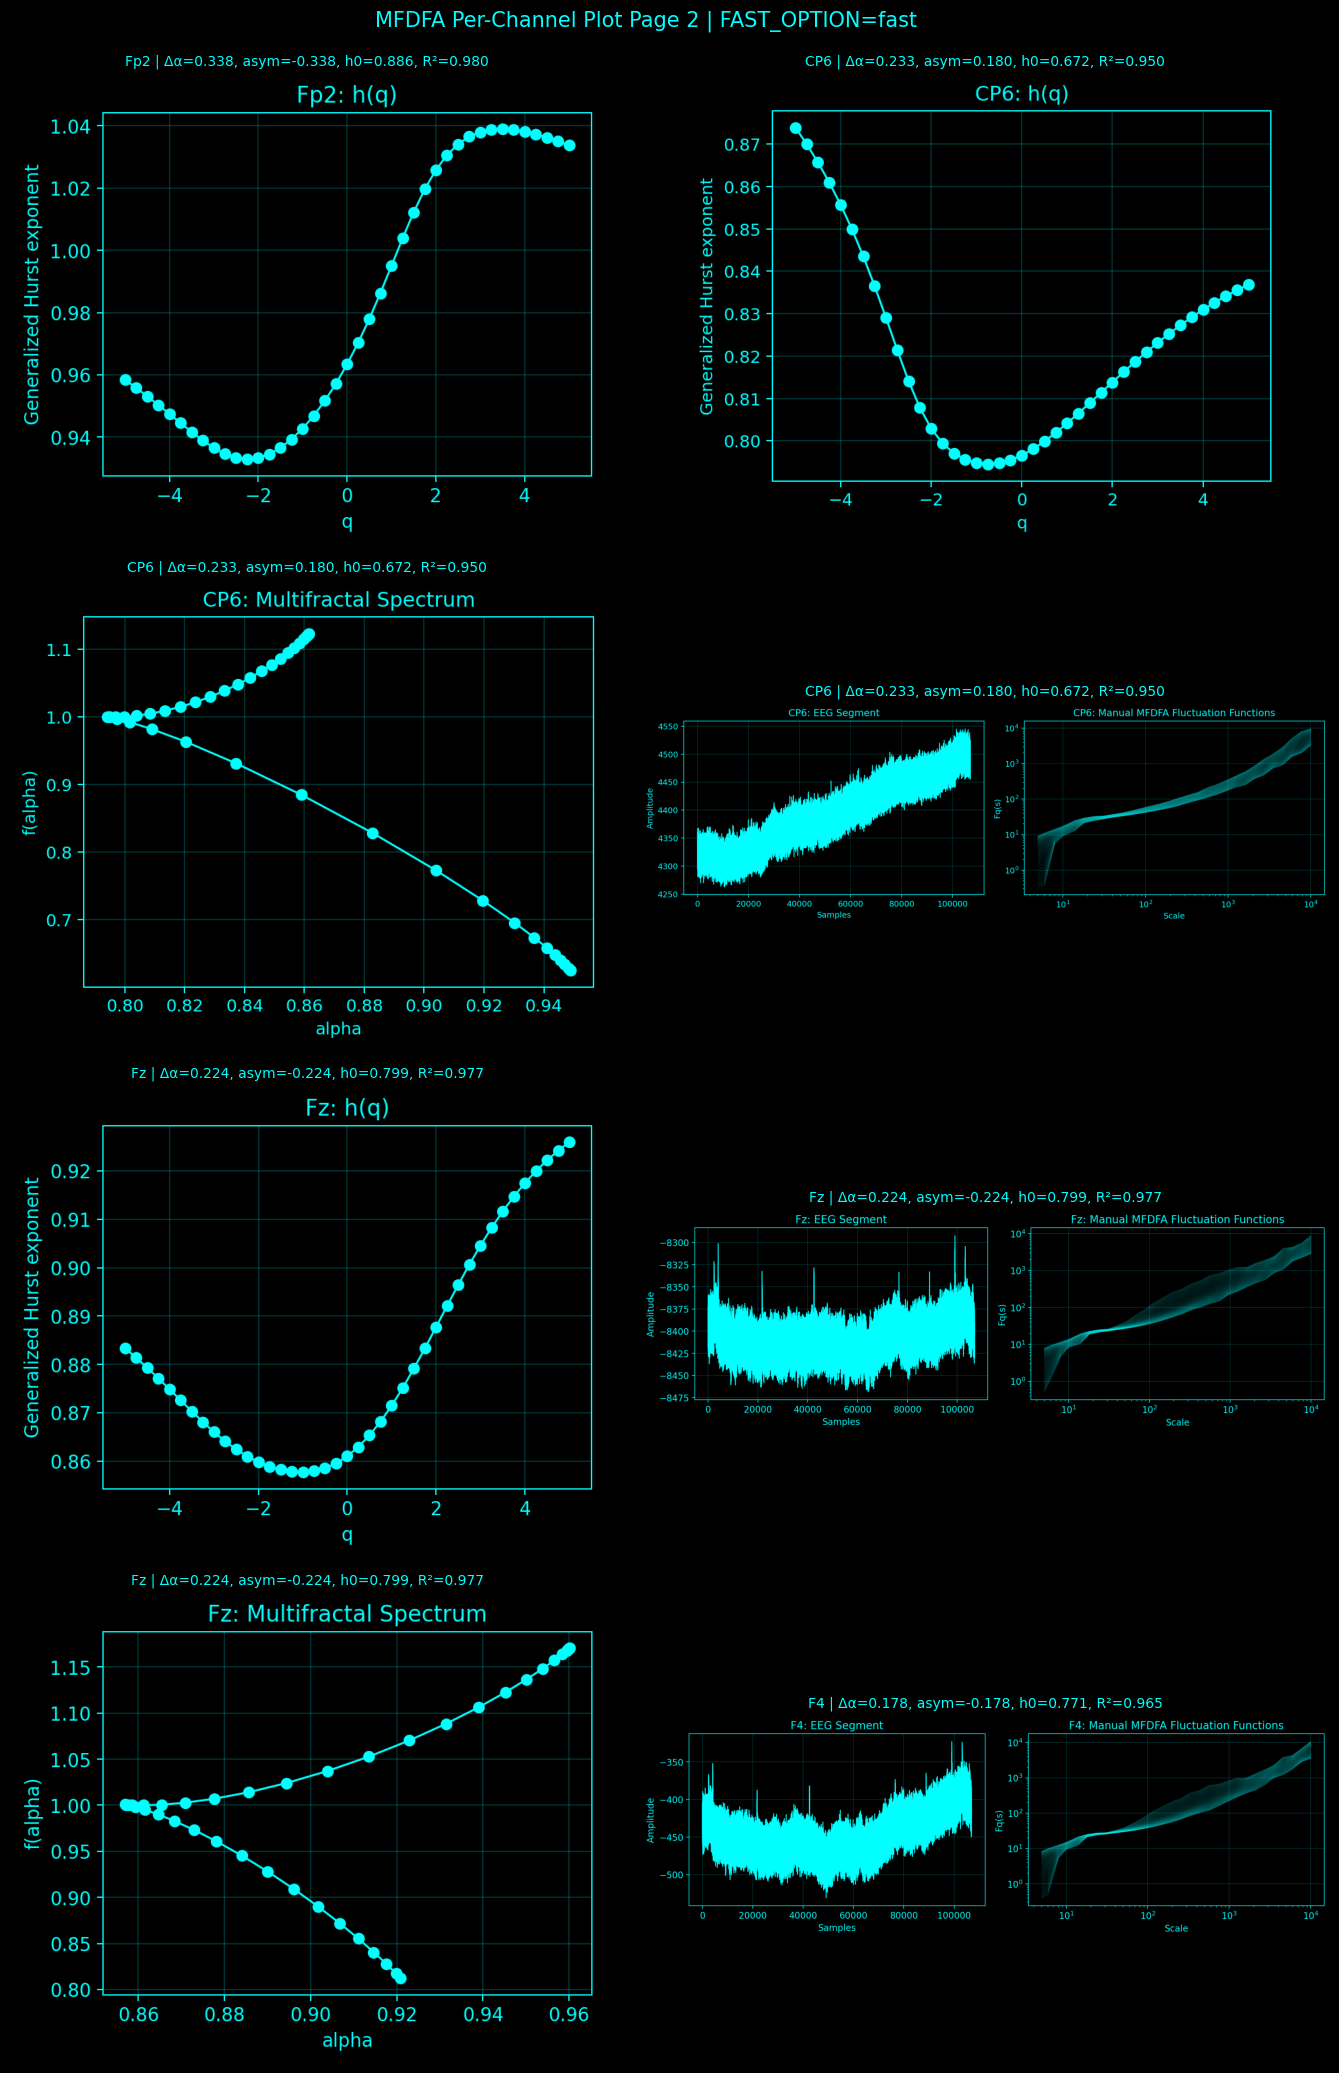

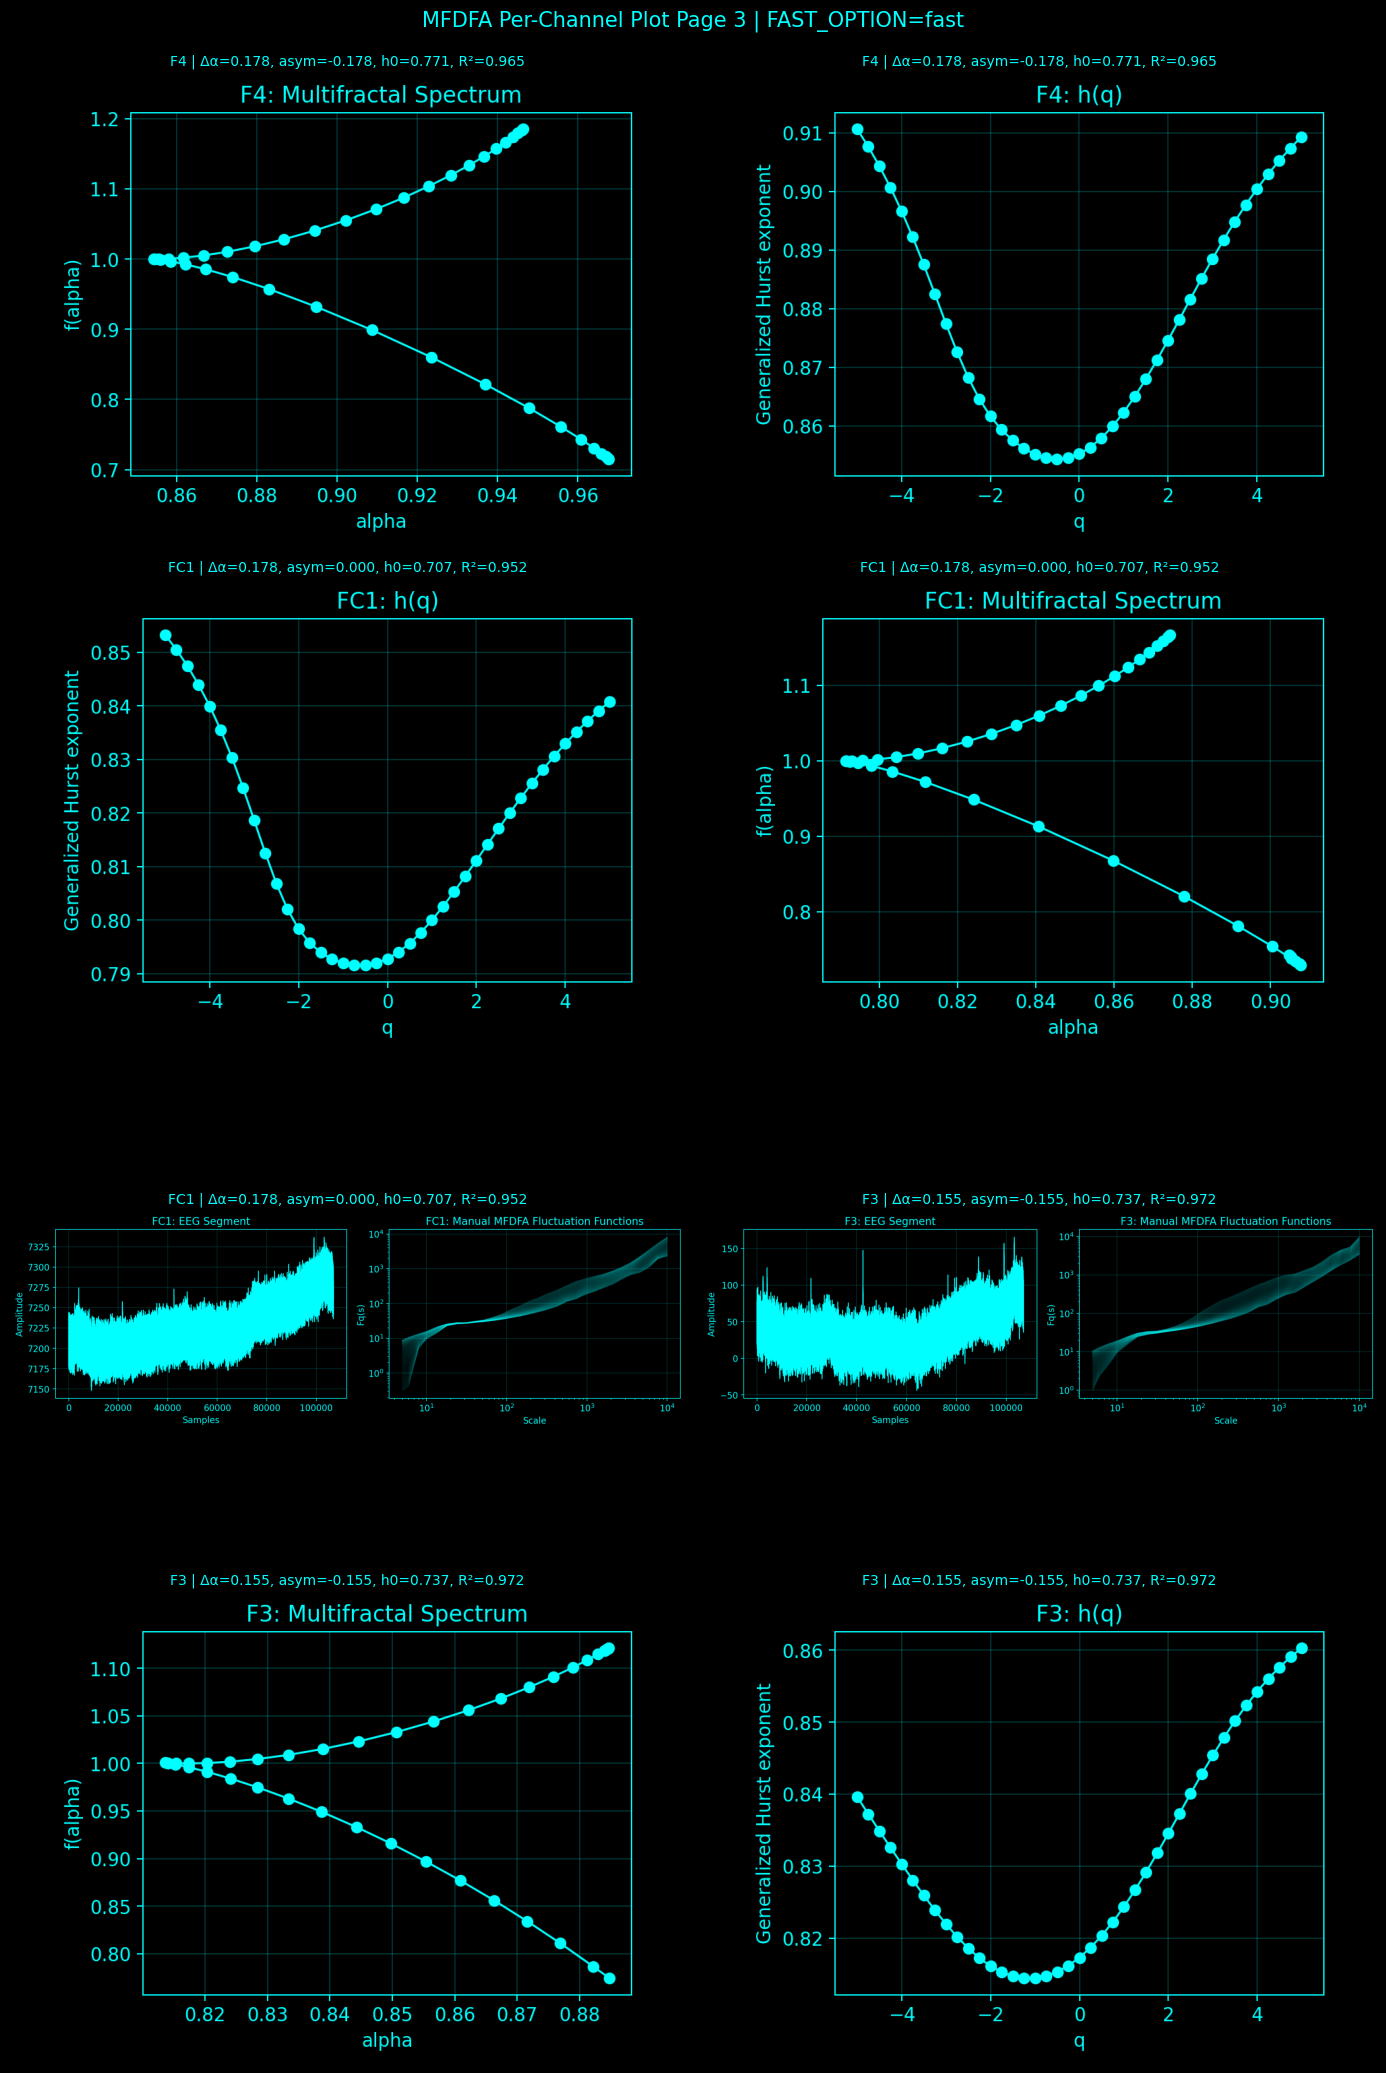

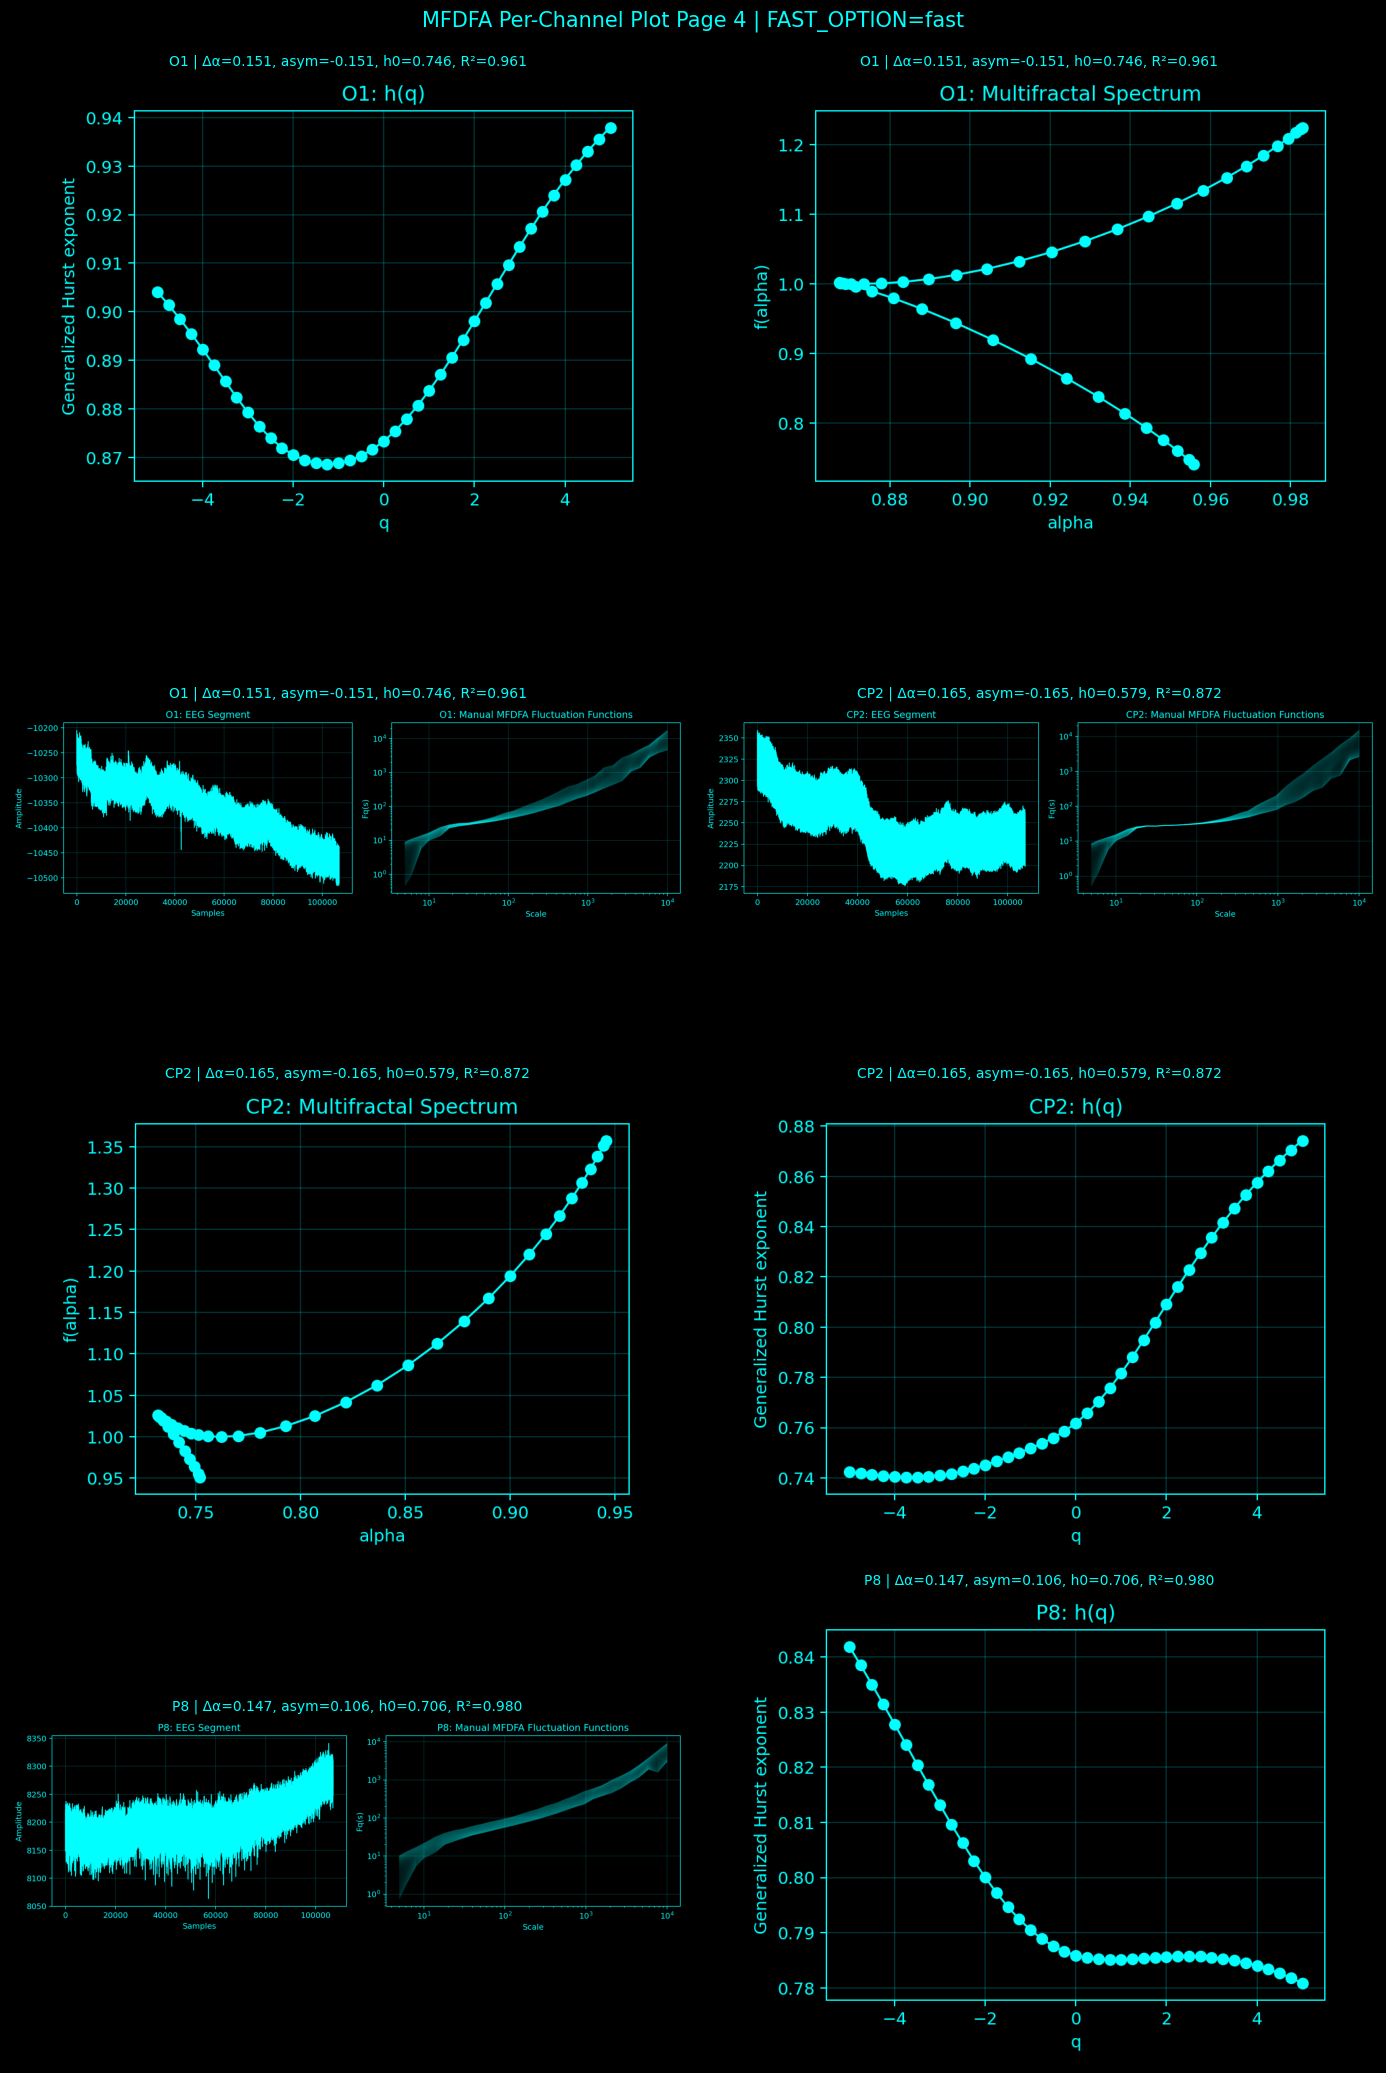

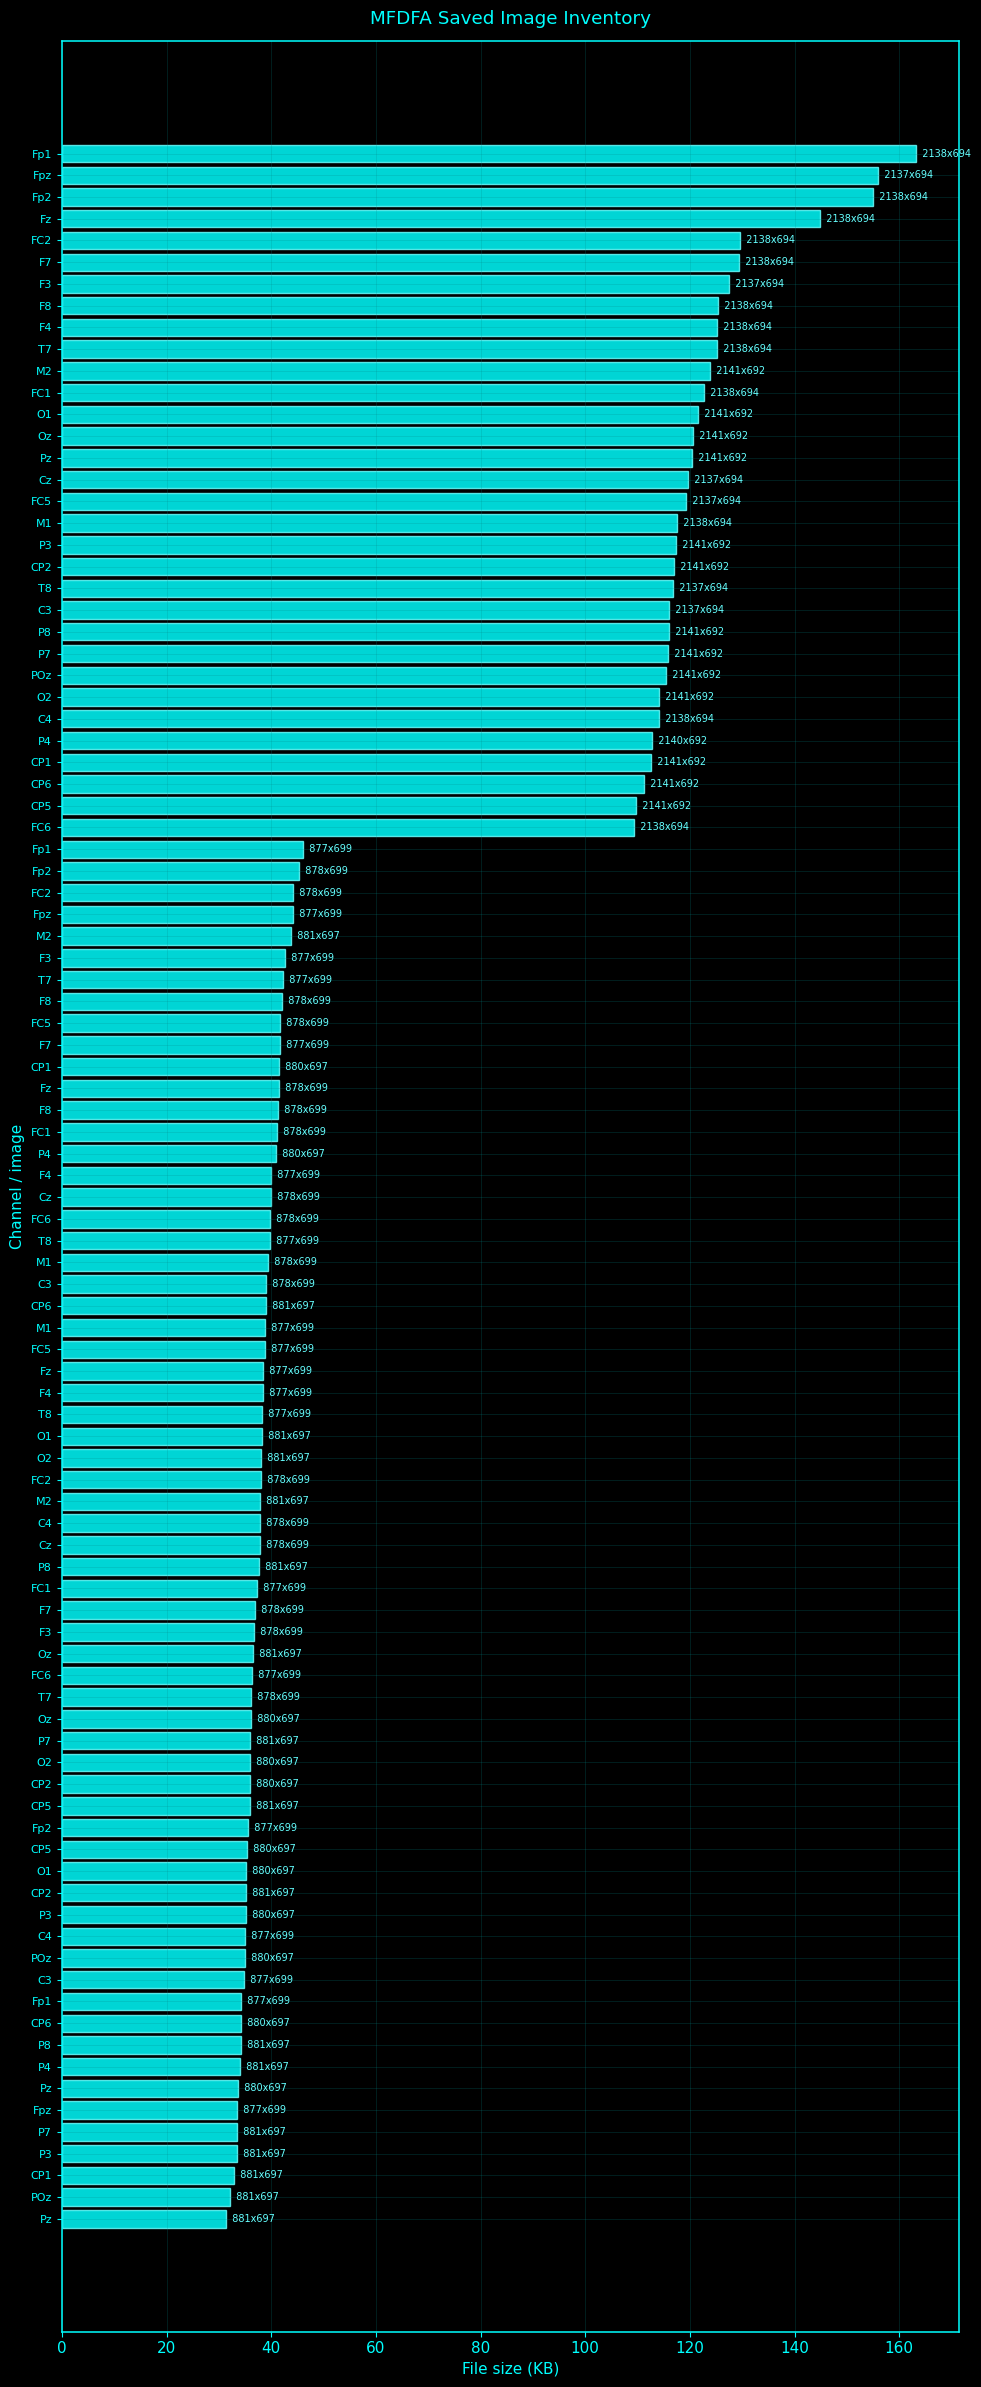

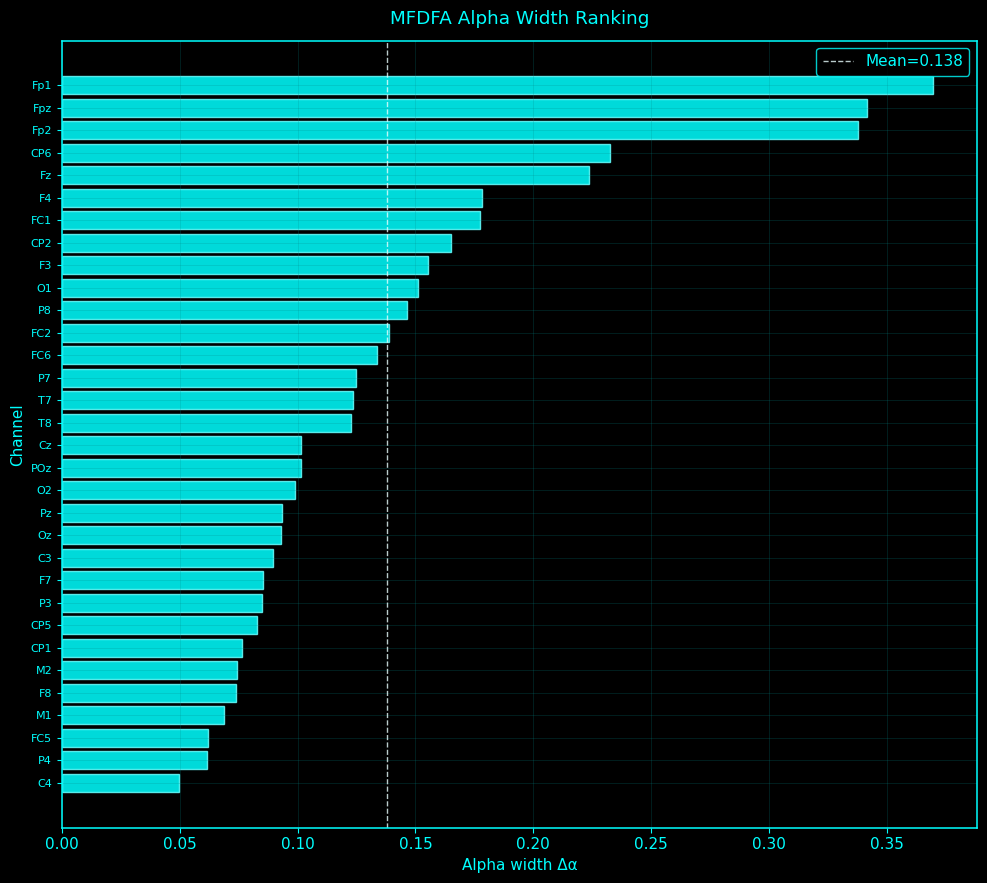

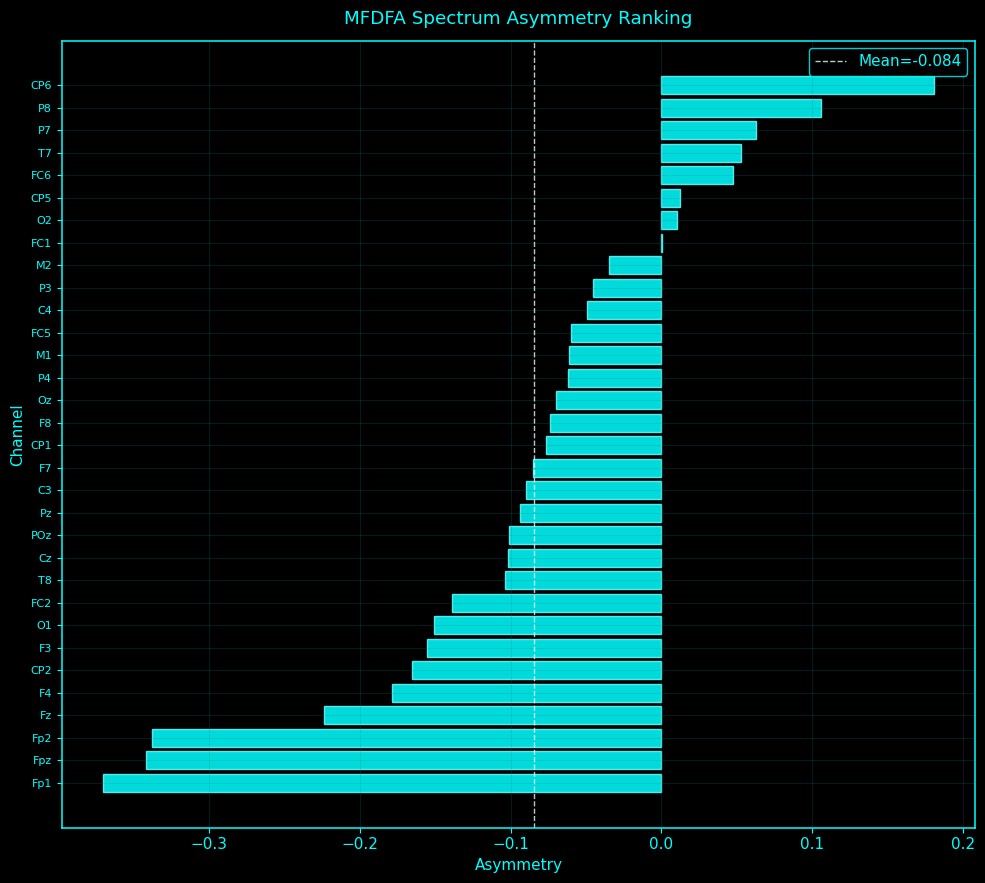

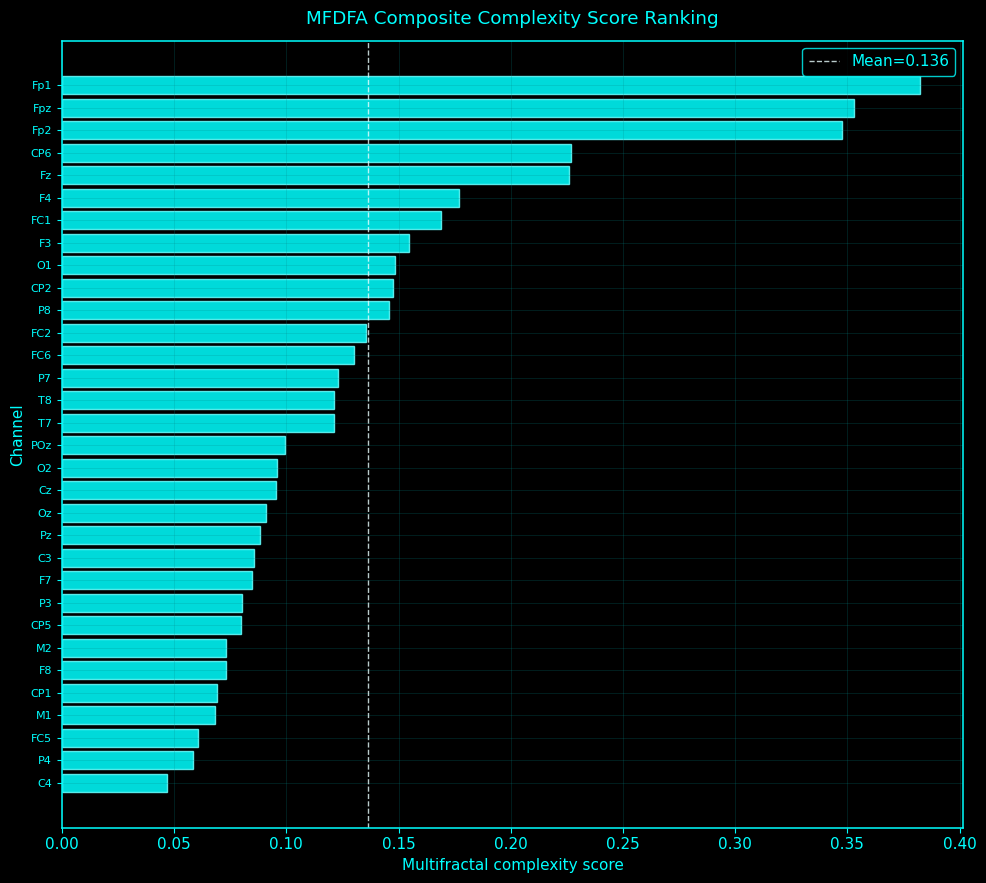

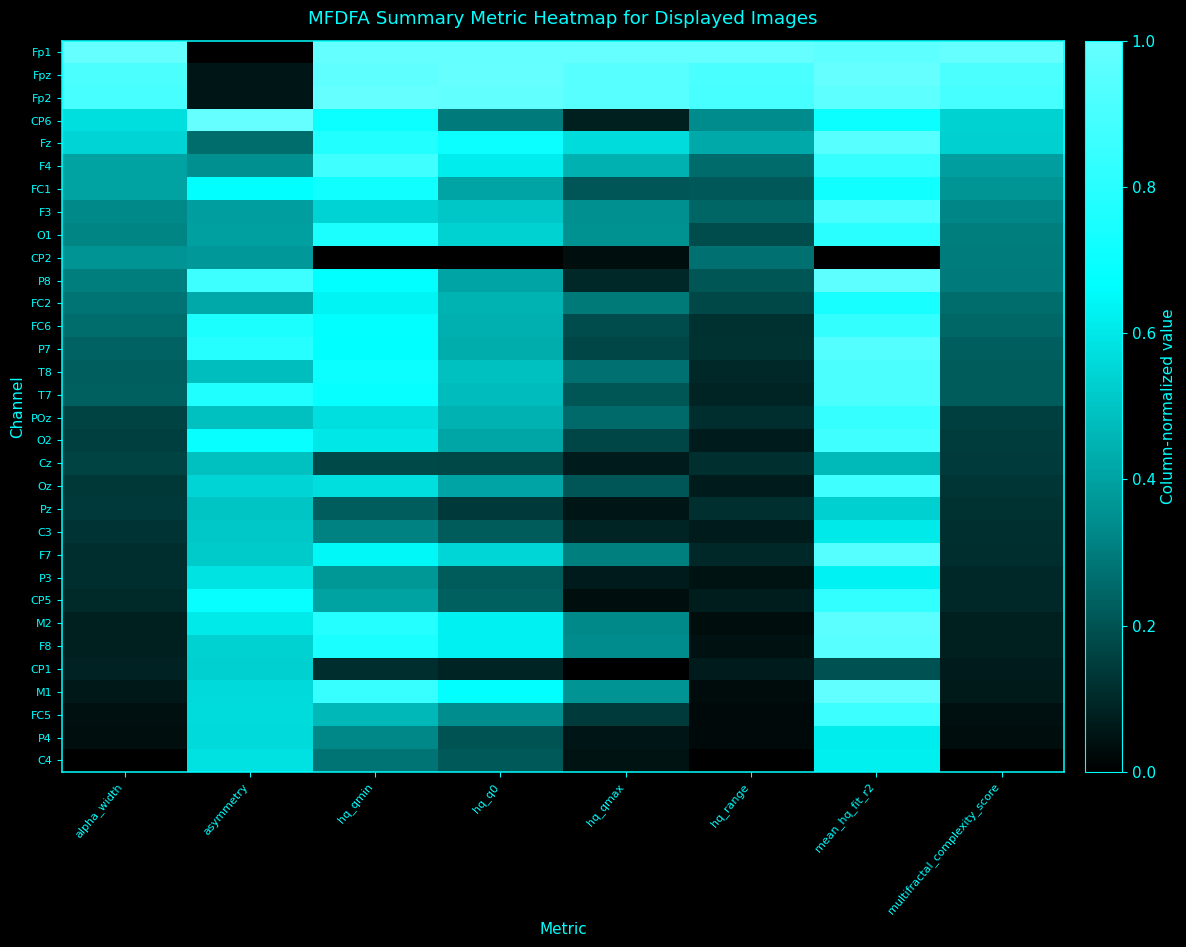

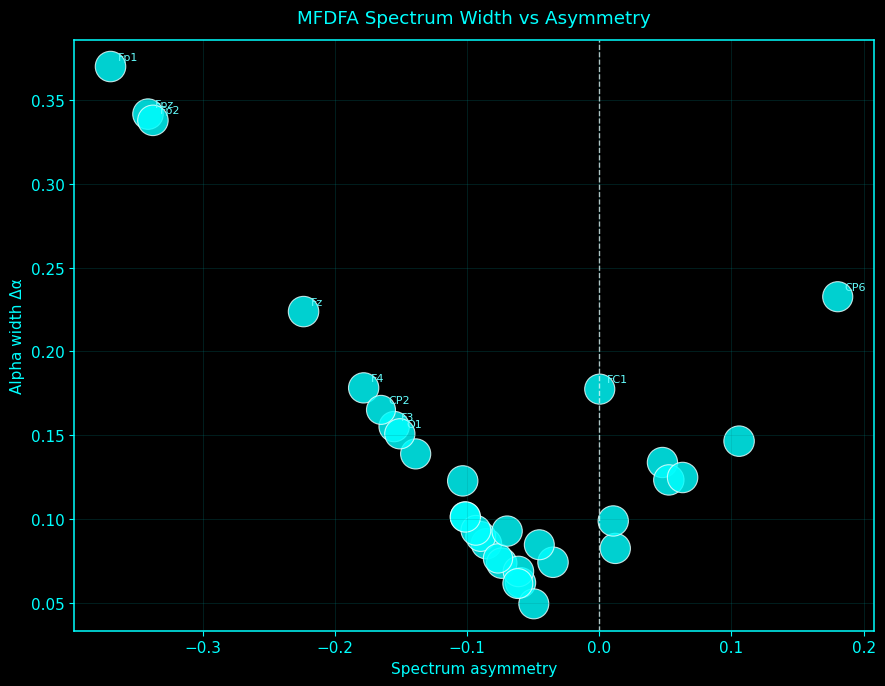


MFDFA PLOT VIEWER SUMMARY
FAST_OPTION: fast
Image directory: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel
Images found: 96
Images displayed: 32
Summary CSV found: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual_expert_fast/mfdfa_summary_ultra.csv
Manifest CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_plot_viewer_expert_fast/mfdfa_image_manifest_fast.csv
Ranked display CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_plot_viewer_expert_fast/mfdfa_display_manifest_ranked_fast.csv
Elapsed: 24.34 sec

Top channels by multifractal_complexity_score:
channel  alpha_width  asymmetry    hq_q0  mean_hq_fit_r2  multifractal_complexity_score
    Fp1     0.369818  -0.369818 0.888154        0.979719                       0.382417
    Fpz     0.341461  -0.341461 0.890523        0.982953                       0.352831
    Fp2     0.337733  -0.337733 0.886121        0.979767                       

In [1]:
import os
import glob
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

FAST_OPTION = "fast"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    show_contact_sheet_first = True
    show_individual_pages = True
    save_new_contact_sheets = True
    save_expert_summary_plots = True
    max_images_to_show = 16
    plots_per_page = 8
    ncols = 2
    figure_scale = 0.85
    dpi_save = 170
    sort_mode = "alpha_width"
    make_ranked_galleries = True
    make_metric_plots = True
    make_image_inventory_plots = True

elif FAST_OPTION == "fast":
    show_contact_sheet_first = True
    show_individual_pages = True
    save_new_contact_sheets = True
    save_expert_summary_plots = True
    max_images_to_show = 32
    plots_per_page = 8
    ncols = 2
    figure_scale = 1.00
    dpi_save = 190
    sort_mode = "multifractal_complexity_score"
    make_ranked_galleries = True
    make_metric_plots = True
    make_image_inventory_plots = True

elif FAST_OPTION == "balanced":
    show_contact_sheet_first = True
    show_individual_pages = True
    save_new_contact_sheets = True
    save_expert_summary_plots = True
    max_images_to_show = None
    plots_per_page = 8
    ncols = 2
    figure_scale = 1.05
    dpi_save = 220
    sort_mode = "multifractal_complexity_score"
    make_ranked_galleries = True
    make_metric_plots = True
    make_image_inventory_plots = True

elif FAST_OPTION == "full":
    show_contact_sheet_first = True
    show_individual_pages = True
    save_new_contact_sheets = True
    save_expert_summary_plots = True
    max_images_to_show = None
    plots_per_page = 6
    ncols = 2
    figure_scale = 1.15
    dpi_save = 240
    sort_mode = "multifractal_complexity_score"
    make_ranked_galleries = True
    make_metric_plots = True
    make_image_inventory_plots = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


candidate_img_dirs = [
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "plots", "per_channel"),
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "plots", "per_channel_all_41_Fq"),
    os.path.join(base_dir, "results", "mfdfa_manual", "plots", "per_channel_all_41_Fq"),
    os.path.join(base_dir, "results", "mfdfa_manual", "plots", "per_channel"),
]

candidate_summary_csvs = [
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", f"mfdfa_summary_{FAST_OPTION}.csv"),
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "mfdfa_summary_fast.csv"),
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "mfdfa_summary_balanced.csv"),
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "mfdfa_summary_full.csv"),
    os.path.join(base_dir, "results", "mfdfa_manual_expert_fast", "mfdfa_summary_ultra.csv"),
    os.path.join(base_dir, "results", "mfdfa_manual", "mfdfa_summary.csv"),
]

viewer_out_dir = os.path.join(base_dir, "results", "mfdfa_plot_viewer_expert_fast")
viewer_plot_dir = os.path.join(viewer_out_dir, "plots")
viewer_contact_dir = os.path.join(viewer_plot_dir, "contact_sheets")
viewer_expert_dir = os.path.join(viewer_plot_dir, "expert_summary")

os.makedirs(viewer_out_dir, exist_ok=True)
os.makedirs(viewer_plot_dir, exist_ok=True)
os.makedirs(viewer_contact_dir, exist_ok=True)
os.makedirs(viewer_expert_dir, exist_ok=True)


ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)
    if show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif show:
        plt.show()
    plt.close(fig)


def short_label(x, max_len=30):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def channel_from_filename(path):
    name = os.path.basename(path)
    suffixes = [
        "_all_41_Fq_curves.png",
        "_signal_and_Fq_fast.png",
        "_signal_and_Fq_balanced.png",
        "_signal_and_Fq_full.png",
        "_signal_and_Fq_ultra.png",
        "_signal_and_Fq.png",
        "_hq_fast.png",
        "_hq_balanced.png",
        "_hq_full.png",
        "_hq_ultra.png",
        "_hq.png",
        "_multifractal_spectrum_fast.png",
        "_multifractal_spectrum_balanced.png",
        "_multifractal_spectrum_full.png",
        "_multifractal_spectrum_ultra.png",
        "_multifractal_spectrum.png",
    ]
    for s in suffixes:
        if name.endswith(s):
            return name.replace(s, "")
    return os.path.splitext(name)[0]


def find_existing_img_dir():
    existing = []
    for d in candidate_img_dirs:
        if os.path.isdir(d):
            pngs = glob.glob(os.path.join(d, "*.png"))
            if len(pngs) > 0:
                existing.append((d, len(pngs)))
    if len(existing) == 0:
        raise FileNotFoundError(
            "No MFDFA image directory with PNG files was found. Checked:\n"
            + "\n".join(candidate_img_dirs)
        )
    existing = sorted(existing, key=lambda x: x[1], reverse=True)
    return existing[0][0]


def find_summary_csv():
    for p in candidate_summary_csvs:
        if os.path.exists(p):
            return p
    matches = []
    for root in [
        os.path.join(base_dir, "results", "mfdfa_manual_expert_fast"),
        os.path.join(base_dir, "results", "mfdfa_manual"),
    ]:
        if os.path.isdir(root):
            matches.extend(glob.glob(os.path.join(root, "*summary*.csv")))
    if len(matches):
        matches = sorted(matches, key=lambda x: os.path.getmtime(x), reverse=True)
        return matches[0]
    return None


def collect_image_manifest(img_dir):
    pngs = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    contact_candidates = [
        os.path.join(img_dir, "all_channels_all_41_Fq_contact_sheet.png"),
        os.path.join(img_dir, "all_channels_contact_sheet.png"),
    ]

    contact_sheet_path = None
    for p in contact_candidates:
        if os.path.exists(p):
            contact_sheet_path = p
            break

    image_paths = []
    for p in pngs:
        name = os.path.basename(p).lower()
        if "contact_sheet" in name:
            continue
        image_paths.append(p)

    rows = []
    for p in image_paths:
        ch = channel_from_filename(p)
        try:
            img = mpimg.imread(p)
            h, w = img.shape[:2]
        except Exception:
            h, w = np.nan, np.nan

        rows.append({
            "channel": ch,
            "image_path": p,
            "filename": os.path.basename(p),
            "file_size_kb": os.path.getsize(p) / 1024.0 if os.path.exists(p) else np.nan,
            "image_width_px": w,
            "image_height_px": h,
            "aspect_ratio": w / h if np.isfinite(w) and np.isfinite(h) and h > 0 else np.nan,
            "modified_time": os.path.getmtime(p) if os.path.exists(p) else np.nan,
        })

    manifest = pd.DataFrame(rows)

    return contact_sheet_path, manifest


def load_summary(summary_csv):
    if summary_csv is None or not os.path.exists(summary_csv):
        return pd.DataFrame()
    try:
        df = pd.read_csv(summary_csv)
        if "channel" not in df.columns:
            return pd.DataFrame()
        return df
    except Exception:
        return pd.DataFrame()


def merge_manifest_summary(manifest_df, summary_df):
    if manifest_df.empty:
        return manifest_df.copy()

    df = manifest_df.copy()

    if not summary_df.empty and "channel" in summary_df.columns:
        cols_to_use = [c for c in summary_df.columns if c not in ["image_path", "filename"]]
        df = df.merge(summary_df[cols_to_use], on="channel", how="left")

    if sort_mode in df.columns:
        df = df.sort_values(sort_mode, ascending=False, na_position="last")
    elif "alpha_width" in df.columns:
        df = df.sort_values("alpha_width", ascending=False, na_position="last")
    elif "file_size_kb" in df.columns:
        df = df.sort_values("file_size_kb", ascending=False, na_position="last")

    if max_images_to_show is not None:
        df_show = df.head(max_images_to_show).copy()
    else:
        df_show = df.copy()

    return df_show


def show_existing_contact_sheet(contact_sheet_path):
    if contact_sheet_path is None or not os.path.exists(contact_sheet_path):
        return None

    img = mpimg.imread(contact_sheet_path)

    fig, ax = plt.subplots(figsize=(16 * figure_scale, 20 * figure_scale), facecolor=BLACK)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Existing Saved Contact Sheet", color=ACCENT, pad=14)

    save_path = os.path.join(viewer_contact_dir, f"00_existing_contact_sheet_viewed_{FAST_OPTION}.png")
    save_fig(fig, save_path, show=True)

    return save_path


def make_contact_sheet_from_paths(df, title, save_name, max_items=None, show=True):
    if df.empty:
        return None

    plot_df = df.copy()

    if max_items is not None:
        plot_df = plot_df.head(max_items).copy()

    n = len(plot_df)

    if n == 0:
        return None

    local_ncols = ncols
    local_nrows = int(math.ceil(n / local_ncols))

    fig_w = 7.0 * local_ncols * figure_scale
    fig_h = 4.8 * local_nrows * figure_scale

    fig, axes = plt.subplots(local_nrows, local_ncols, figsize=(fig_w, fig_h), facecolor=BLACK, squeeze=False)
    axes_flat = axes.ravel()

    for ax in axes_flat:
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes_flat, plot_df.iterrows()):
        path = row["image_path"]

        try:
            img = mpimg.imread(path)
            ax.imshow(img)
        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"Could not load image\n{type(e).__name__}",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color=ACCENT,
            )

        title_parts = [str(row["channel"])]

        if "alpha_width" in row and np.isfinite(row.get("alpha_width", np.nan)):
            title_parts.append(f"Δα={row['alpha_width']:.3f}")

        if "multifractal_complexity_score" in row and np.isfinite(row.get("multifractal_complexity_score", np.nan)):
            title_parts.append(f"score={row['multifractal_complexity_score']:.3f}")

        if "mean_hq_fit_r2" in row and np.isfinite(row.get("mean_hq_fit_r2", np.nan)):
            title_parts.append(f"R²={row['mean_hq_fit_r2']:.2f}")

        ax.set_title(" | ".join(title_parts), color=ACCENT, fontsize=10)
        ax.axis("off")

    fig.suptitle(title, color=ACCENT, fontsize=16, y=0.995)

    save_path = os.path.join(viewer_contact_dir, save_name)
    save_fig(fig, save_path, show=show)

    return save_path


def show_individual_image_pages(df):
    paths = []

    if df.empty:
        return paths

    for start in range(0, len(df), plots_per_page):
        batch = df.iloc[start:start + plots_per_page].copy()
        page_num = start // plots_per_page + 1
        nrows = int(math.ceil(len(batch) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(14 * figure_scale, 5.2 * nrows * figure_scale),
            facecolor=BLACK,
            squeeze=False,
        )

        axes = axes.ravel()

        for ax in axes:
            ax.set_facecolor(BLACK)
            ax.axis("off")

        for ax, (_, row) in zip(axes, batch.iterrows()):
            path = row["image_path"]
            try:
                img = mpimg.imread(path)
                ax.imshow(img)
            except Exception as e:
                ax.text(
                    0.5,
                    0.5,
                    f"Could not load\n{os.path.basename(path)}\n{type(e).__name__}",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    color=ACCENT,
                )

            title = str(row["channel"])

            metric_bits = []
            for col, label in [
                ("alpha_width", "Δα"),
                ("asymmetry", "asym"),
                ("hq_q0", "h0"),
                ("mean_hq_fit_r2", "R²"),
            ]:
                if col in row and np.isfinite(row.get(col, np.nan)):
                    metric_bits.append(f"{label}={row[col]:.3f}")

            if len(metric_bits):
                title += " | " + ", ".join(metric_bits)

            ax.set_title(title, color=ACCENT, fontsize=10)
            ax.axis("off")

        fig.suptitle(
            f"MFDFA Per-Channel Plot Page {page_num} | FAST_OPTION={FAST_OPTION}",
            color=ACCENT,
            fontsize=15,
            y=0.995,
        )

        save_path = os.path.join(viewer_contact_dir, f"individual_page_{page_num:02d}_{FAST_OPTION}.png")
        save_fig(fig, save_path, show=True)
        paths.append(save_path)

    return paths


def plot_image_inventory(manifest_df):
    if manifest_df.empty:
        return None

    df = manifest_df.copy().sort_values("file_size_kb", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, 0.25 * len(df))))

    y = np.arange(len(df))

    ax.barh(
        y,
        df["file_size_kb"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.84,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df.iterrows()):
        if np.isfinite(row.get("image_width_px", np.nan)) and np.isfinite(row.get("image_height_px", np.nan)):
            label = f"  {int(row['image_width_px'])}x{int(row['image_height_px'])}"
        else:
            label = ""
        ax.text(row["file_size_kb"], yi, label, va="center", color=ACCENT_SOFT, fontsize=7)

    style_ax(
        ax,
        title="MFDFA Saved Image Inventory",
        xlabel="File size (KB)",
        ylabel="Channel / image",
    )

    path = os.path.join(viewer_expert_dir, f"image_inventory_{FAST_OPTION}.png")
    save_fig(fig, path, show=True)

    return path


def plot_metric_ranking(summary_df, metric_col, title, xlabel, save_name):
    if summary_df.empty or metric_col not in summary_df.columns:
        return None

    df = summary_df.copy()
    df = df[np.isfinite(df[metric_col])].sort_values(metric_col, ascending=True)

    if df.empty:
        return None

    if max_images_to_show is not None:
        df = df.tail(max_images_to_show).copy()

    fig, ax = plt.subplots(figsize=(10, max(6, 0.28 * len(df))))

    y = np.arange(len(df))

    ax.barh(
        y,
        df[metric_col],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    mean_val = df[metric_col].mean()
    ax.axvline(mean_val, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.80, label=f"Mean={mean_val:.3f}")

    style_ax(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(viewer_expert_dir, save_name)
    save_fig(fig, path, show=True)

    return path


def plot_summary_metric_heatmap(summary_df):
    if summary_df.empty:
        return None

    metric_cols = [
        "alpha_width",
        "asymmetry",
        "hq_qmin",
        "hq_q0",
        "hq_qmax",
        "hq_range",
        "mean_hq_fit_r2",
        "multifractal_complexity_score",
    ]

    metric_cols = [c for c in metric_cols if c in summary_df.columns]

    if len(metric_cols) == 0:
        return None

    df = summary_df.copy()

    if sort_mode in df.columns:
        df = df.sort_values(sort_mode, ascending=False, na_position="last")
    elif "alpha_width" in df.columns:
        df = df.sort_values("alpha_width", ascending=False, na_position="last")

    if max_images_to_show is not None:
        df = df.head(max_images_to_show).copy()

    M = df[metric_cols].to_numpy(dtype=float)
    M_norm = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        col = M[:, j]
        finite = col[np.isfinite(col)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            continue

        M_norm[:, j] = (col - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)

    fig, ax = plt.subplots(figsize=(12, max(7, 0.30 * len(df))))

    im = ax.imshow(
        M_norm,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=50, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="MFDFA Summary Metric Heatmap for Displayed Images",
        xlabel="Metric",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Column-normalized value", color=ACCENT)

    path = os.path.join(viewer_expert_dir, f"summary_metric_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path, show=True)

    return path


def plot_width_vs_asymmetry(summary_df):
    needed = ["alpha_width", "asymmetry"]

    if summary_df.empty or any(c not in summary_df.columns for c in needed):
        return None

    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"]) & np.isfinite(df["asymmetry"])]

    if df.empty:
        return None

    if "mean_hq_fit_r2" in df.columns:
        sizes = 70 + 420 * np.clip(df["mean_hq_fit_r2"].fillna(0).to_numpy(dtype=float), 0, 1)
    else:
        sizes = 110

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(
        df["asymmetry"],
        df["alpha_width"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.82,
    )

    ax.axvline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    rank_col = sort_mode if sort_mode in df.columns else "alpha_width"

    for _, row in df.sort_values(rank_col, ascending=False).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["asymmetry"], row["alpha_width"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="MFDFA Spectrum Width vs Asymmetry",
        xlabel="Spectrum asymmetry",
        ylabel="Alpha width Δα",
    )

    path = os.path.join(viewer_expert_dir, f"width_vs_asymmetry_scatter_{FAST_OPTION}.png")
    save_fig(fig, path, show=True)

    return path


start_time_run = time.perf_counter()

print("Running expert MFDFA plot viewer", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)

img_dir = find_existing_img_dir()
summary_csv = find_summary_csv()

print(f"Image directory: {img_dir}", flush=True)
print(f"Summary CSV: {summary_csv if summary_csv is not None else 'not found'}", flush=True)

contact_sheet_path, manifest_df = collect_image_manifest(img_dir)
summary_df = load_summary(summary_csv)

if manifest_df.empty and contact_sheet_path is None:
    raise FileNotFoundError(f"No saved PNG plots found in: {img_dir}")

display_df = merge_manifest_summary(manifest_df, summary_df)

manifest_csv = os.path.join(viewer_out_dir, f"mfdfa_image_manifest_{FAST_OPTION}.csv")
display_csv = os.path.join(viewer_out_dir, f"mfdfa_display_manifest_ranked_{FAST_OPTION}.csv")

manifest_df.to_csv(manifest_csv, index=False)
display_df.to_csv(display_csv, index=False)

print(f"Found {len(manifest_df)} per-channel PNGs", flush=True)
print(f"Showing {len(display_df)} images in this mode", flush=True)
print(f"Sort mode: {sort_mode}", flush=True)

saved_paths = []

if show_contact_sheet_first and contact_sheet_path is not None:
    saved_paths.append(show_existing_contact_sheet(contact_sheet_path))

if save_new_contact_sheets and not display_df.empty:
    saved_paths.append(make_contact_sheet_from_paths(
        display_df,
        title=f"Ranked MFDFA Per-Channel Plot Contact Sheet | sorted by {sort_mode} | {FAST_OPTION}",
        save_name=f"01_ranked_contact_sheet_{FAST_OPTION}.png",
        max_items=max_images_to_show,
        show=True,
    ))

if make_ranked_galleries and not display_df.empty and "alpha_width" in display_df.columns:
    top_width = display_df.sort_values("alpha_width", ascending=False, na_position="last")
    saved_paths.append(make_contact_sheet_from_paths(
        top_width,
        title=f"Top MFDFA Images by Alpha Width Δα | {FAST_OPTION}",
        save_name=f"02_top_alpha_width_contact_sheet_{FAST_OPTION}.png",
        max_items=min(12, len(top_width)),
        show=True,
    ))

if make_ranked_galleries and not display_df.empty and "asymmetry" in display_df.columns:
    top_asym = display_df.copy()
    top_asym["abs_asymmetry"] = np.abs(top_asym["asymmetry"])
    top_asym = top_asym.sort_values("abs_asymmetry", ascending=False, na_position="last")
    saved_paths.append(make_contact_sheet_from_paths(
        top_asym,
        title=f"Top MFDFA Images by Absolute Spectrum Asymmetry | {FAST_OPTION}",
        save_name=f"03_top_asymmetry_contact_sheet_{FAST_OPTION}.png",
        max_items=min(12, len(top_asym)),
        show=True,
    ))

if show_individual_pages and not display_df.empty:
    saved_paths.extend(show_individual_image_pages(display_df))

if make_image_inventory_plots:
    saved_paths.append(plot_image_inventory(manifest_df))

if make_metric_plots and not summary_df.empty:
    saved_paths.append(plot_metric_ranking(
        summary_df,
        metric_col="alpha_width",
        title="MFDFA Alpha Width Ranking",
        xlabel="Alpha width Δα",
        save_name=f"alpha_width_ranking_{FAST_OPTION}.png",
    ))

    saved_paths.append(plot_metric_ranking(
        summary_df,
        metric_col="asymmetry",
        title="MFDFA Spectrum Asymmetry Ranking",
        xlabel="Asymmetry",
        save_name=f"asymmetry_ranking_{FAST_OPTION}.png",
    ))

    if "multifractal_complexity_score" in summary_df.columns:
        saved_paths.append(plot_metric_ranking(
            summary_df,
            metric_col="multifractal_complexity_score",
            title="MFDFA Composite Complexity Score Ranking",
            xlabel="Multifractal complexity score",
            save_name=f"complexity_score_ranking_{FAST_OPTION}.png",
        ))

    saved_paths.append(plot_summary_metric_heatmap(summary_df))
    saved_paths.append(plot_width_vs_asymmetry(summary_df))

saved_paths = [p for p in saved_paths if p is not None]

elapsed = time.perf_counter() - start_time_run

print("\n" + "=" * 88)
print("MFDFA PLOT VIEWER SUMMARY")
print("=" * 88)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Image directory: {img_dir}")
print(f"Images found: {len(manifest_df)}")
print(f"Images displayed: {len(display_df)}")
print(f"Summary CSV found: {summary_csv if summary_csv is not None else 'None'}")
print(f"Manifest CSV: {manifest_csv}")
print(f"Ranked display CSV: {display_csv}")
print(f"Elapsed: {elapsed:.2f} sec")

if not summary_df.empty:
    cols = [
        "channel",
        "alpha_width",
        "asymmetry",
        "hq_q0",
        "mean_hq_fit_r2",
        "multifractal_complexity_score",
    ]
    cols = [c for c in cols if c in summary_df.columns]
    rank_col = sort_mode if sort_mode in summary_df.columns else "alpha_width"
    print(f"\nTop channels by {rank_col}:")
    print(summary_df.sort_values(rank_col, ascending=False, na_position="last")[cols].head(15).to_string(index=False))

print("\nSaved viewer plots:")
for p in saved_paths:
    print(p)

print("\nDone.")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


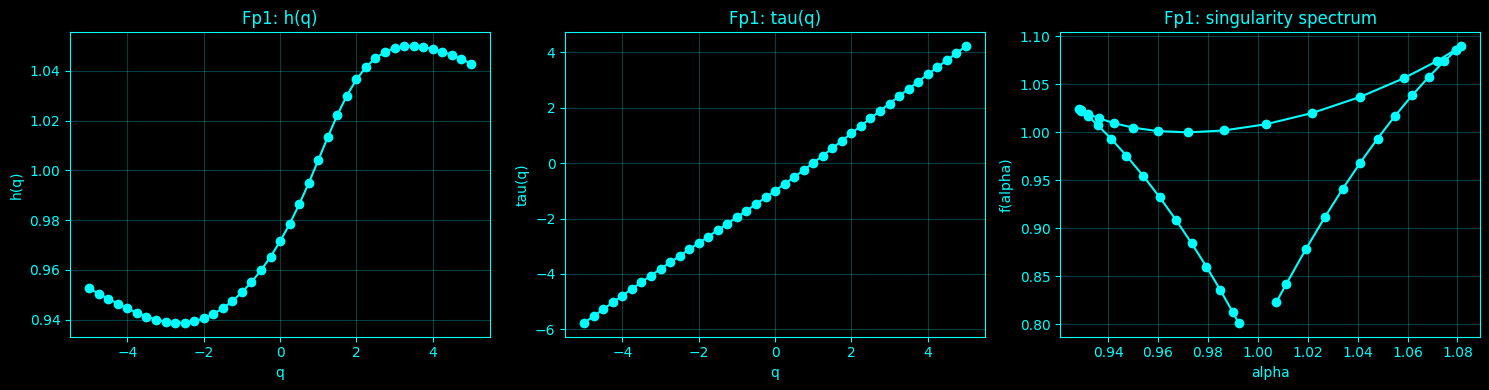

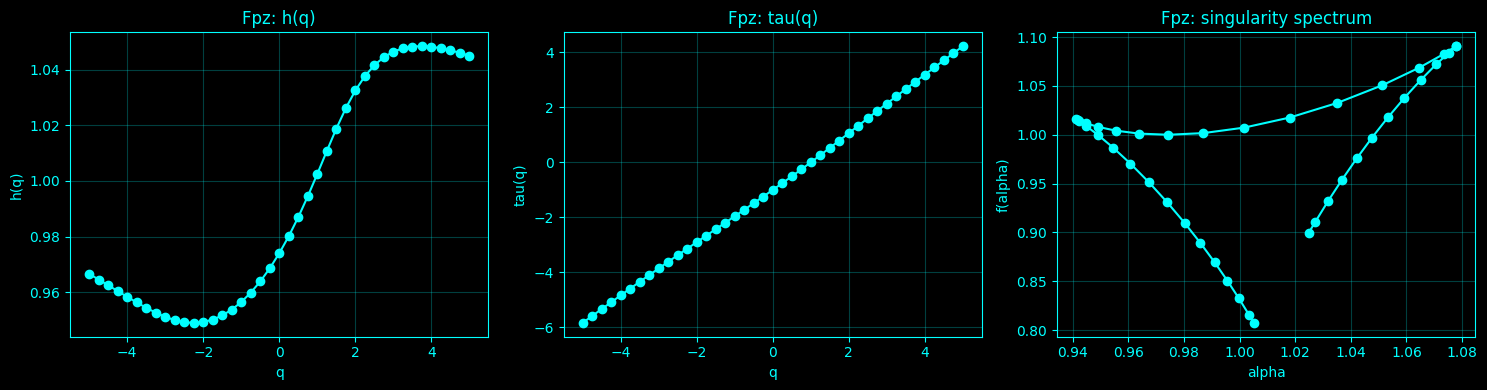

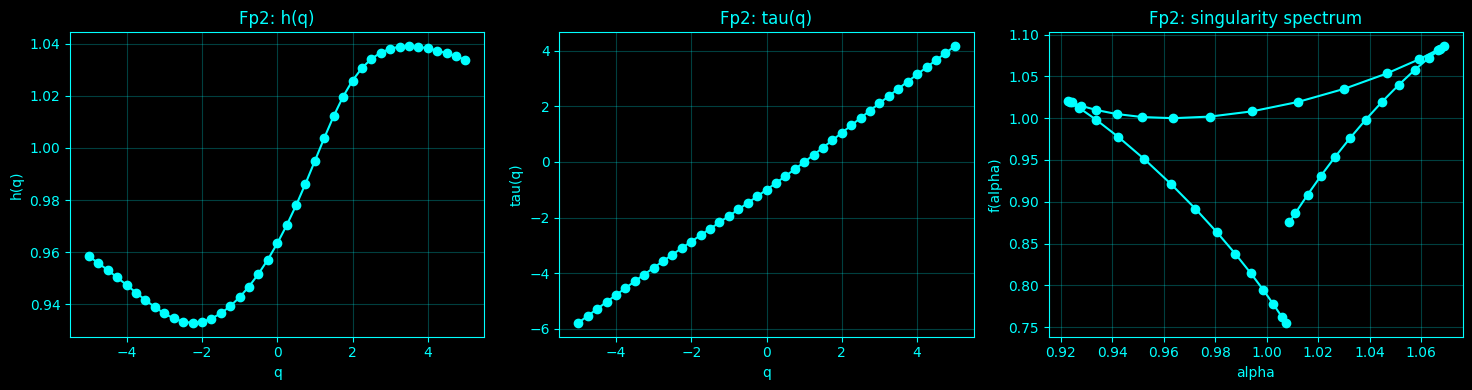

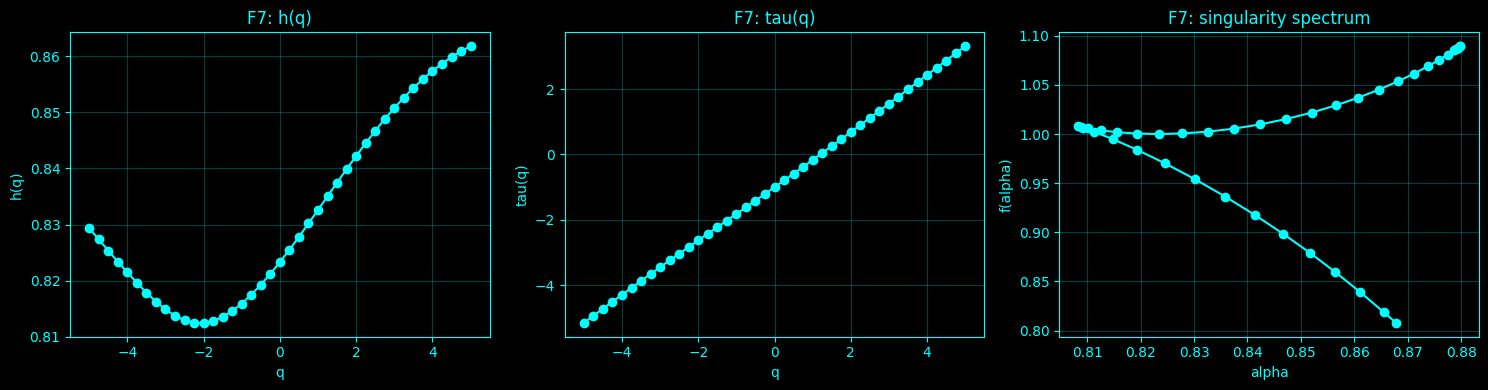

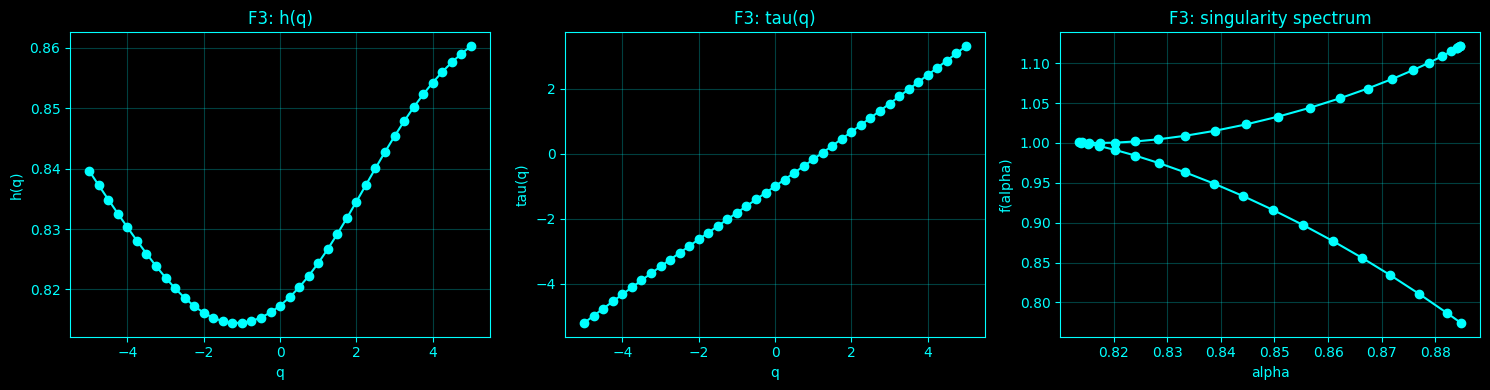

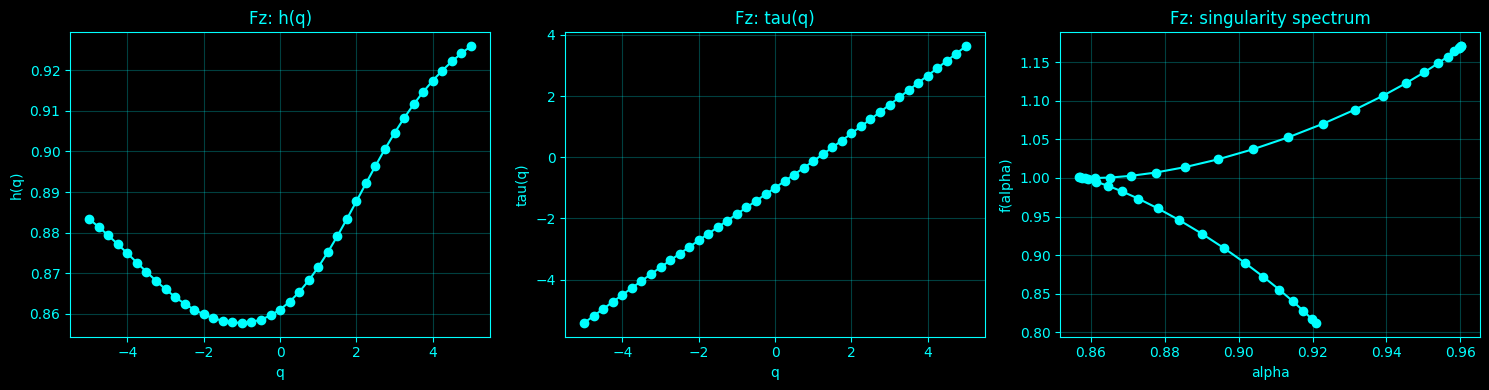

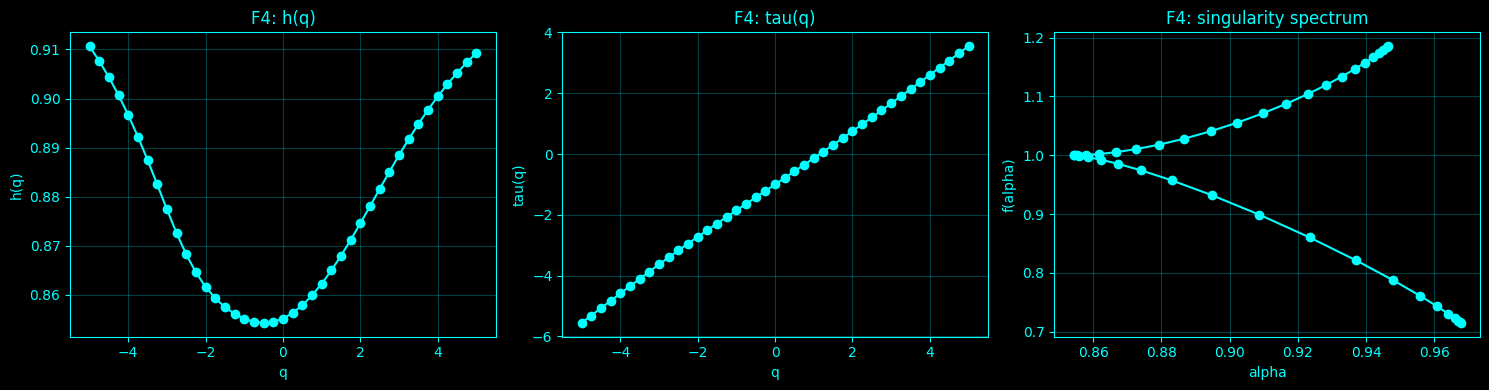

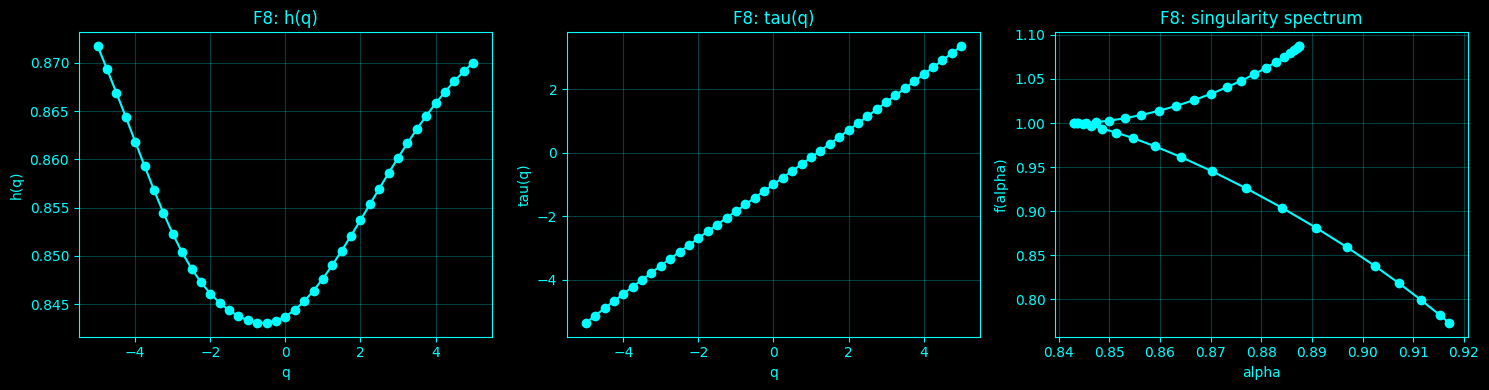

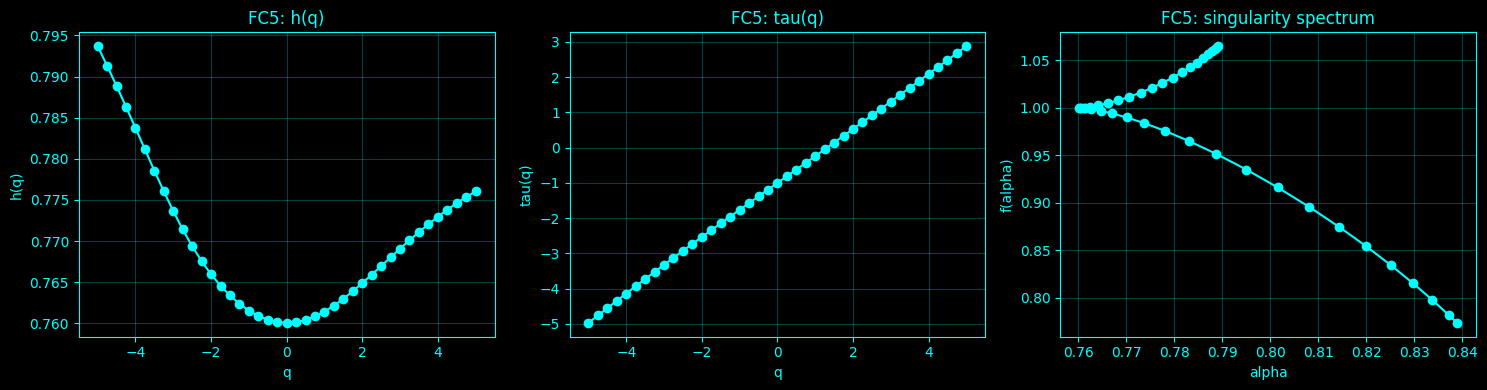

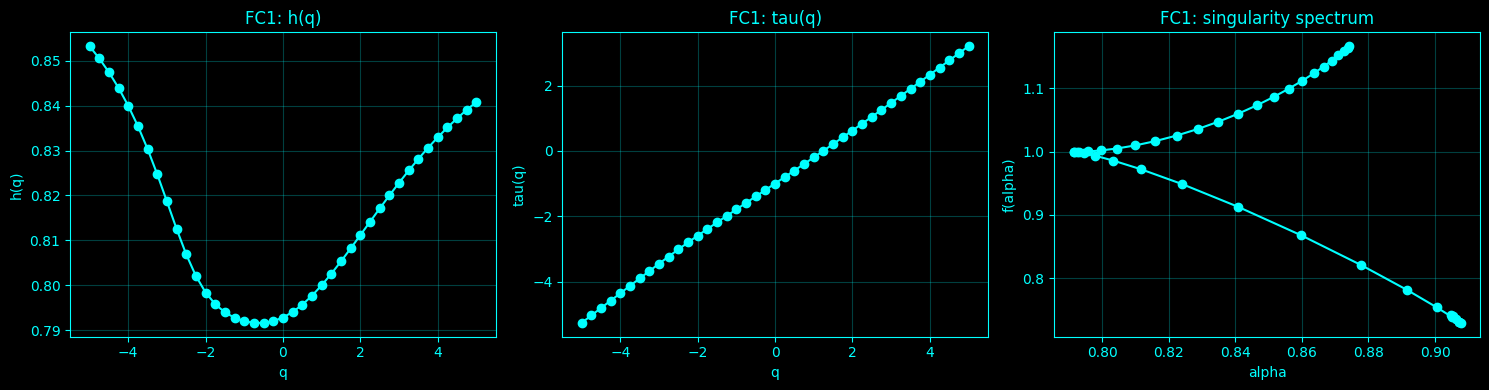

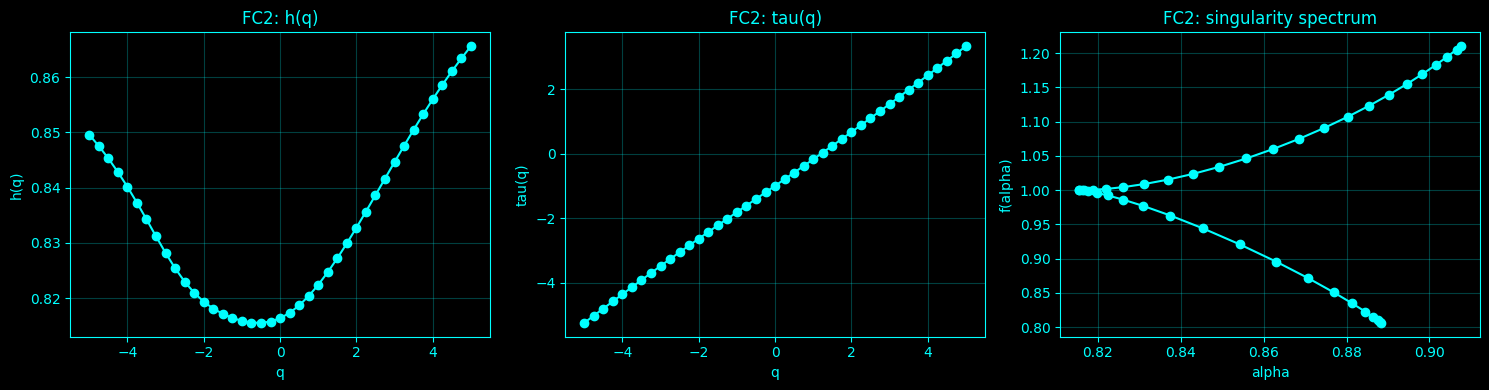

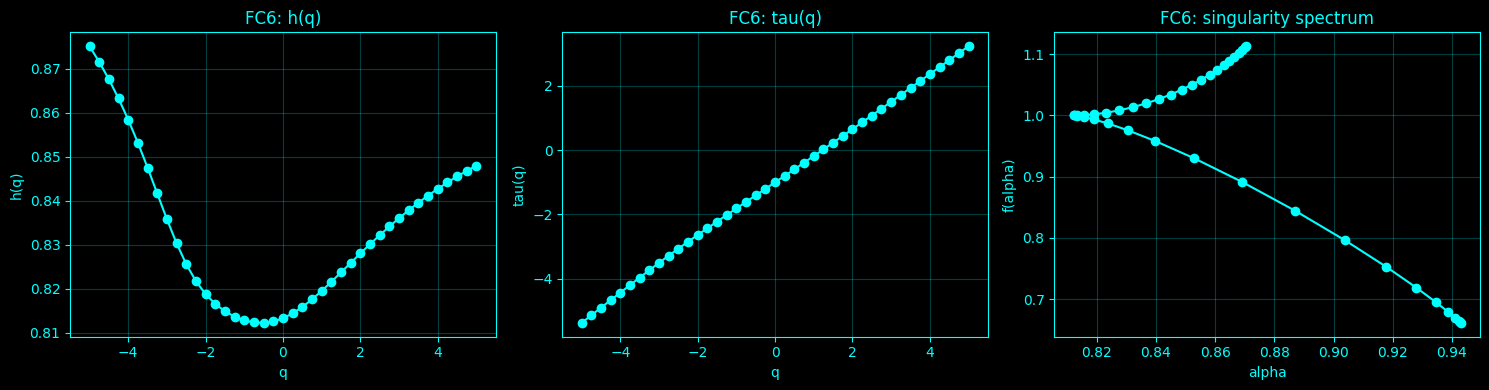

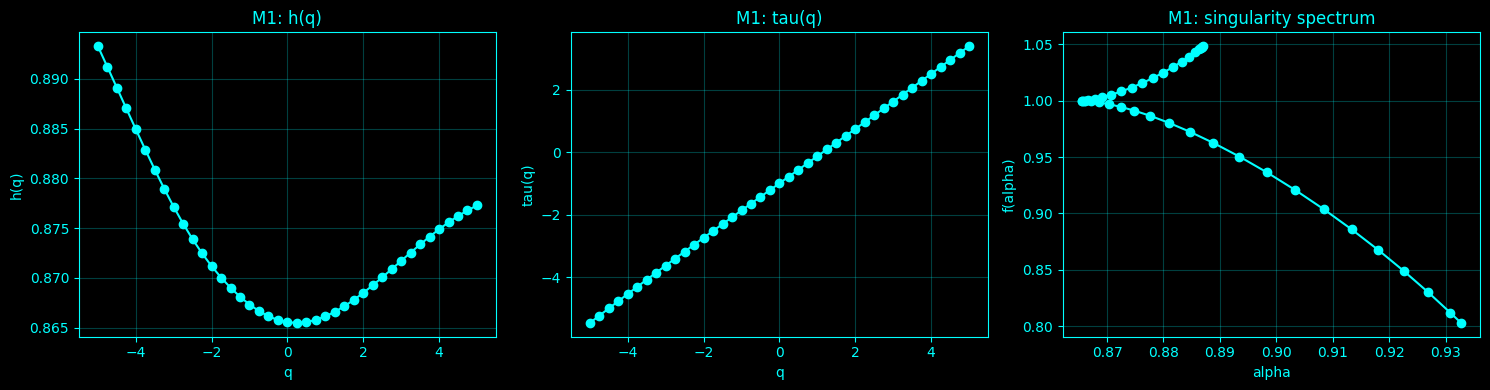

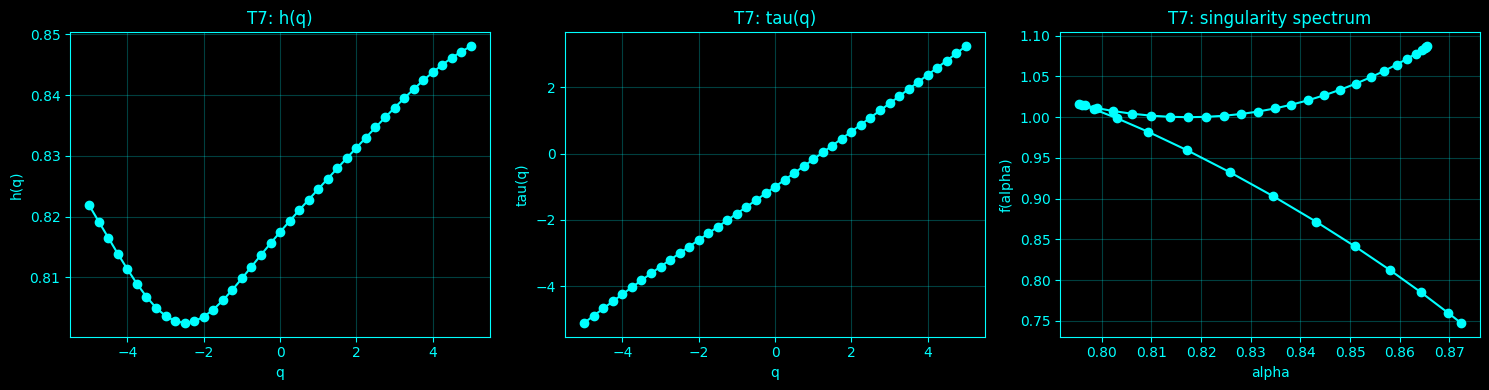

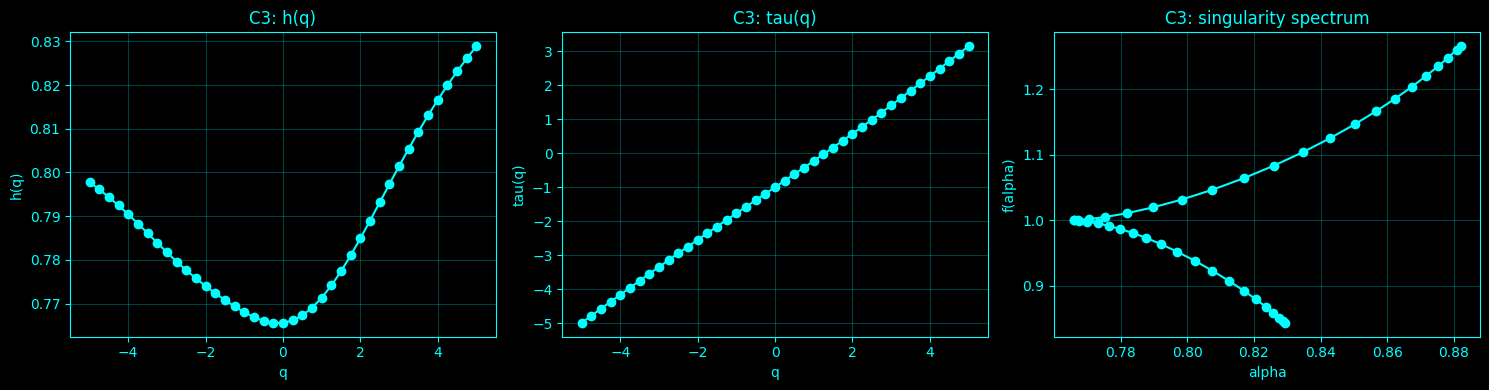

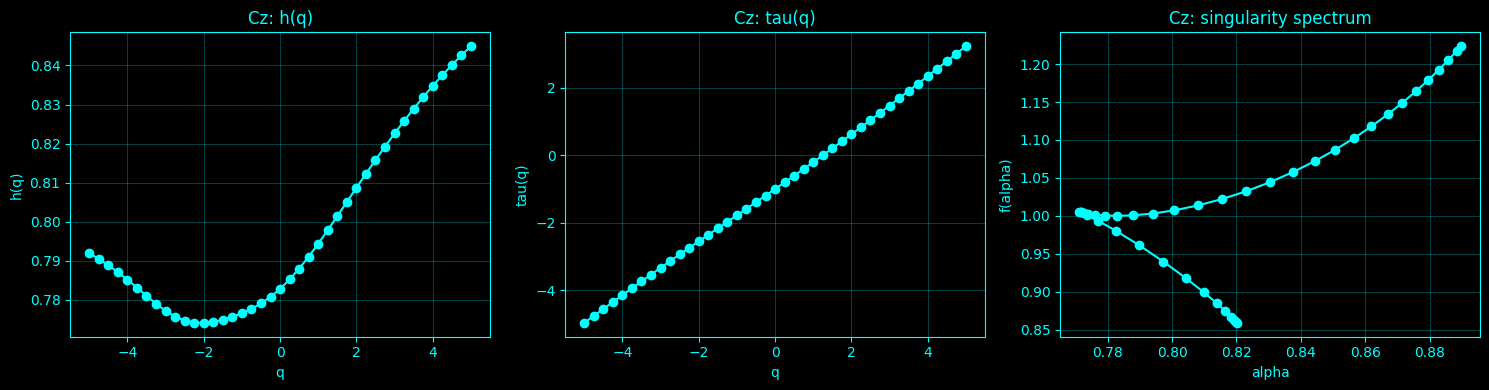

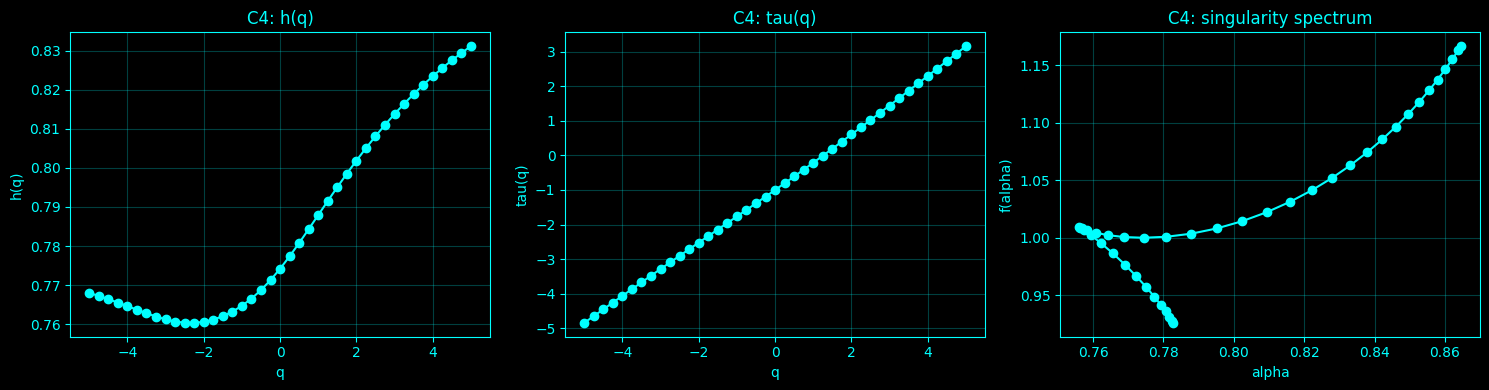

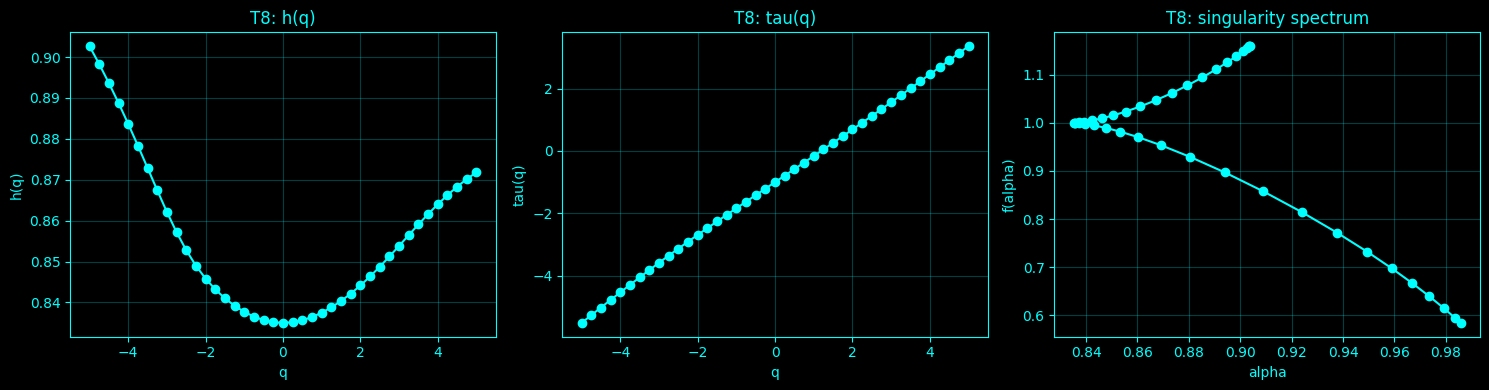

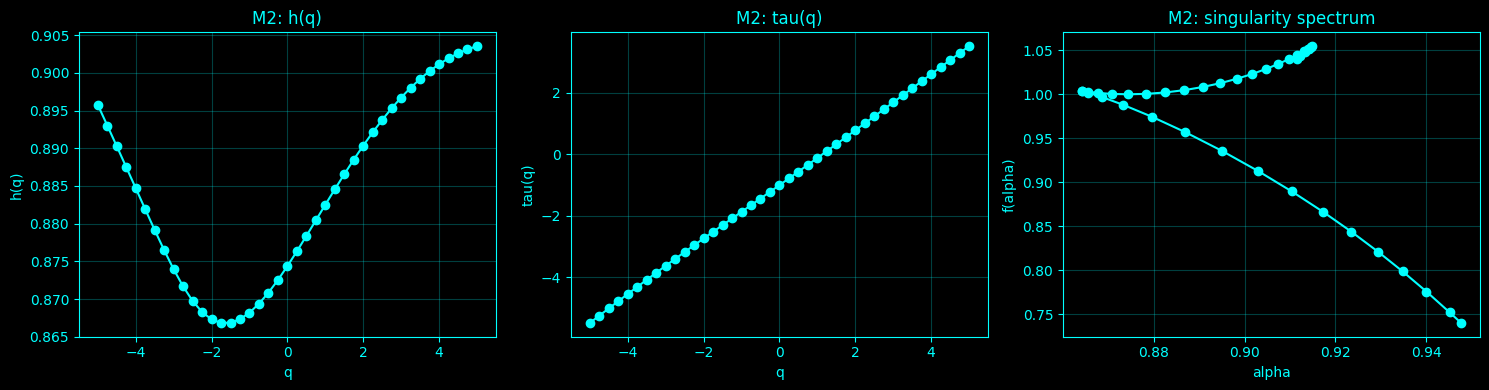

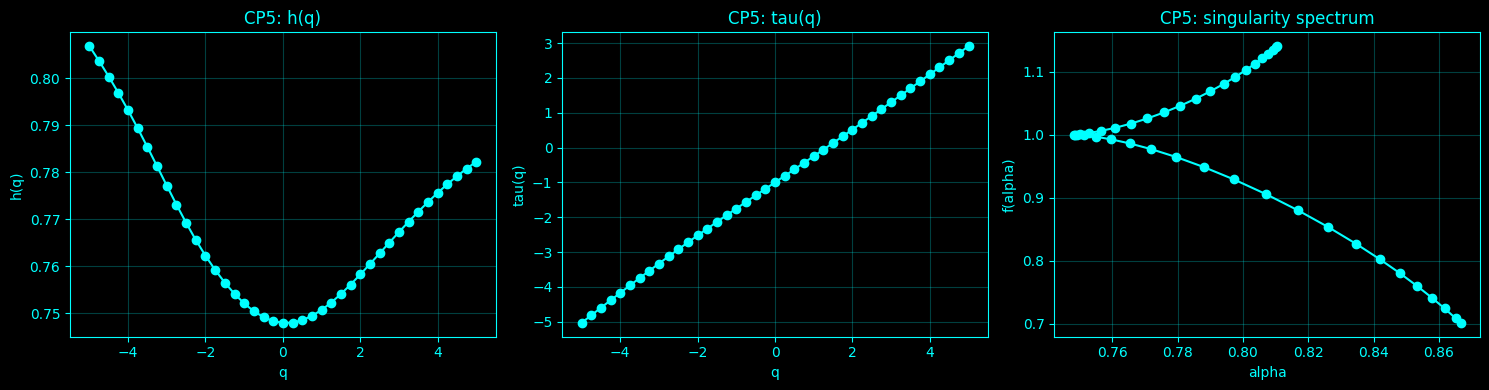

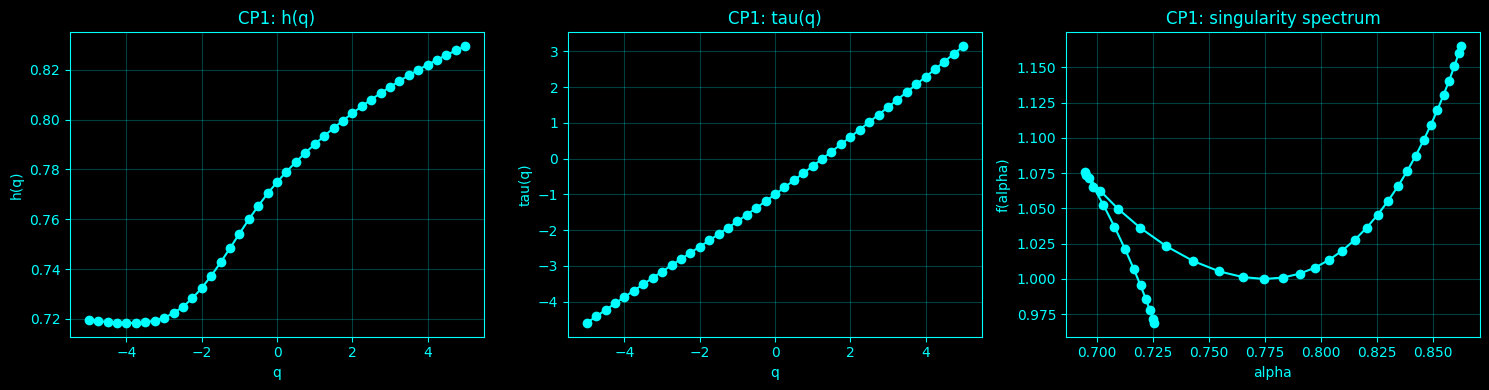

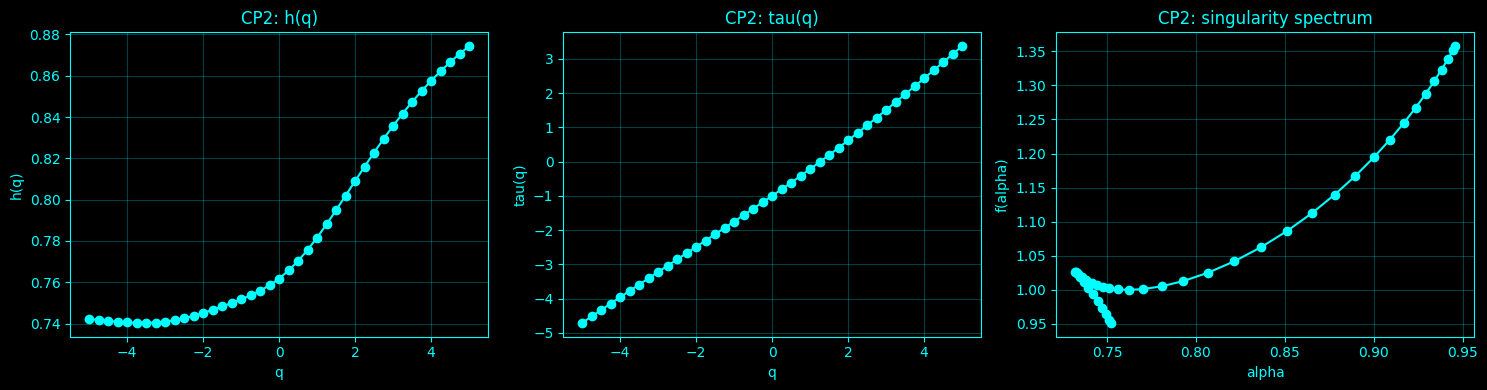

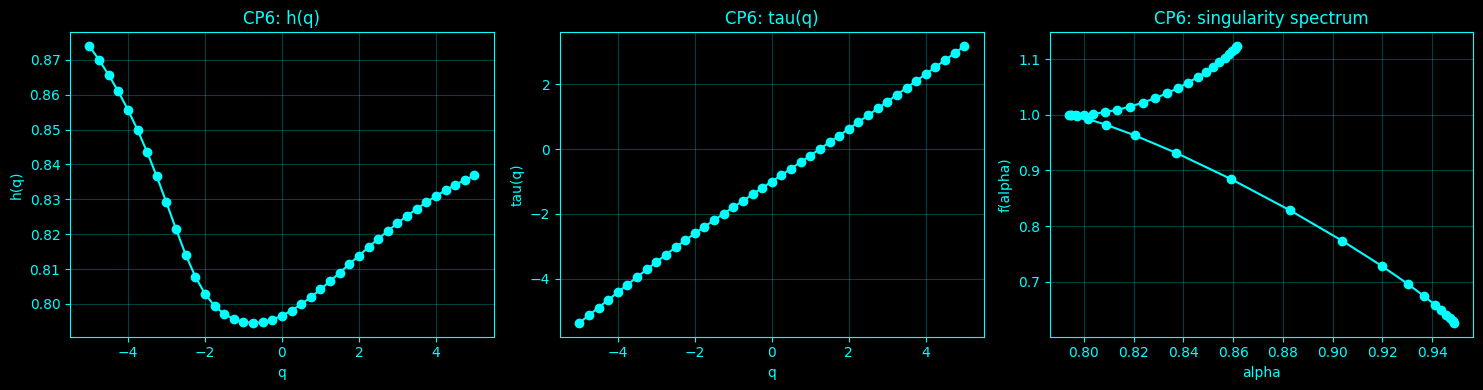

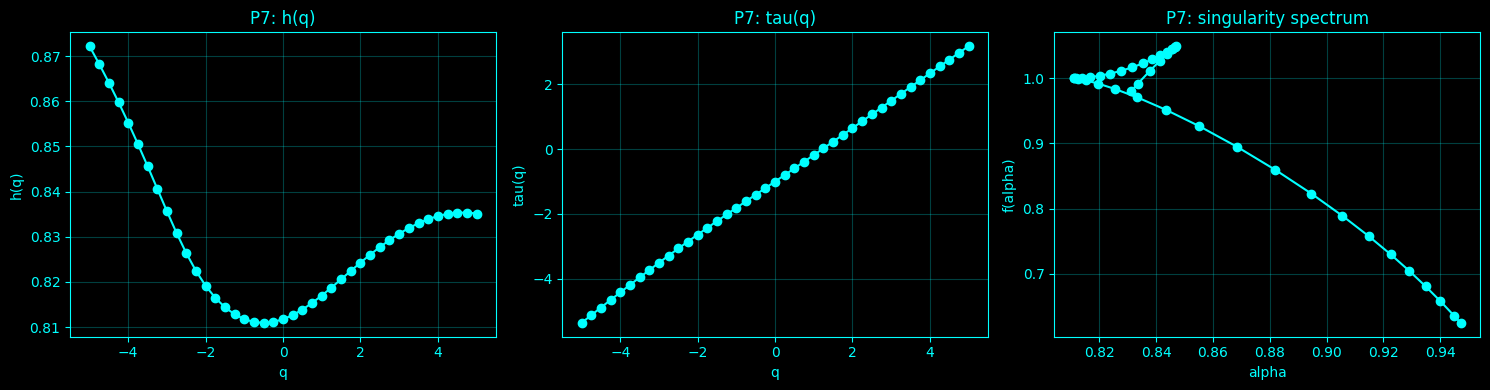

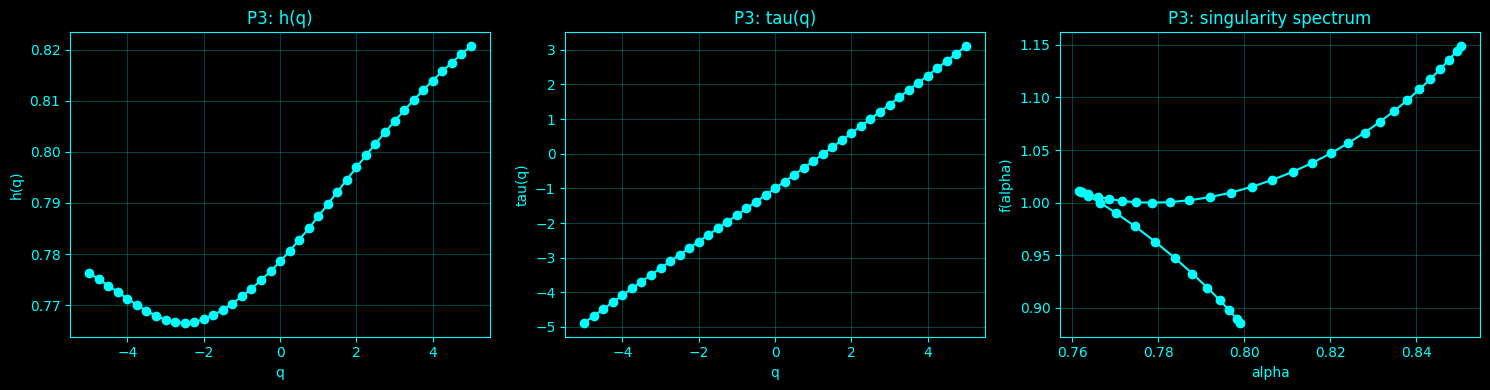

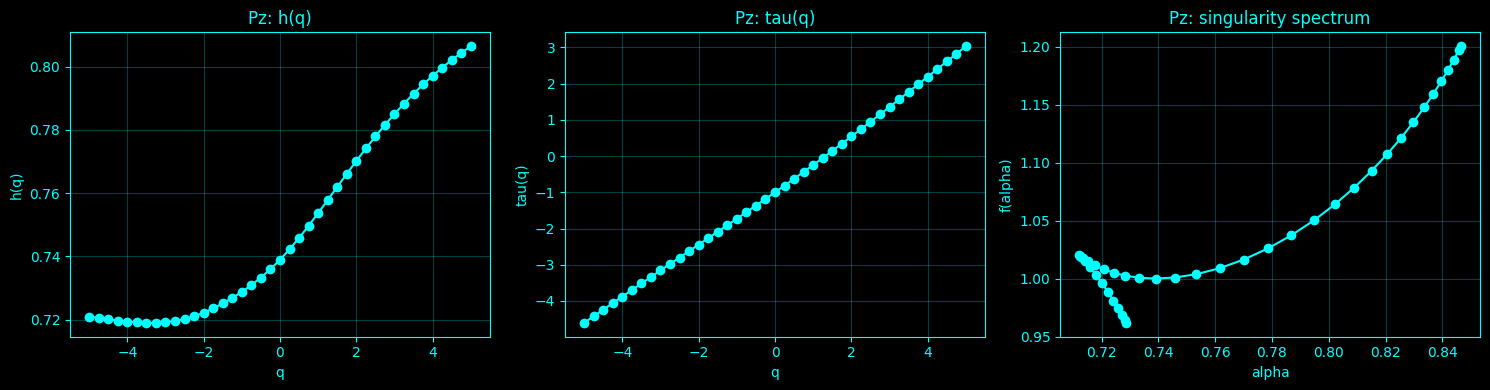

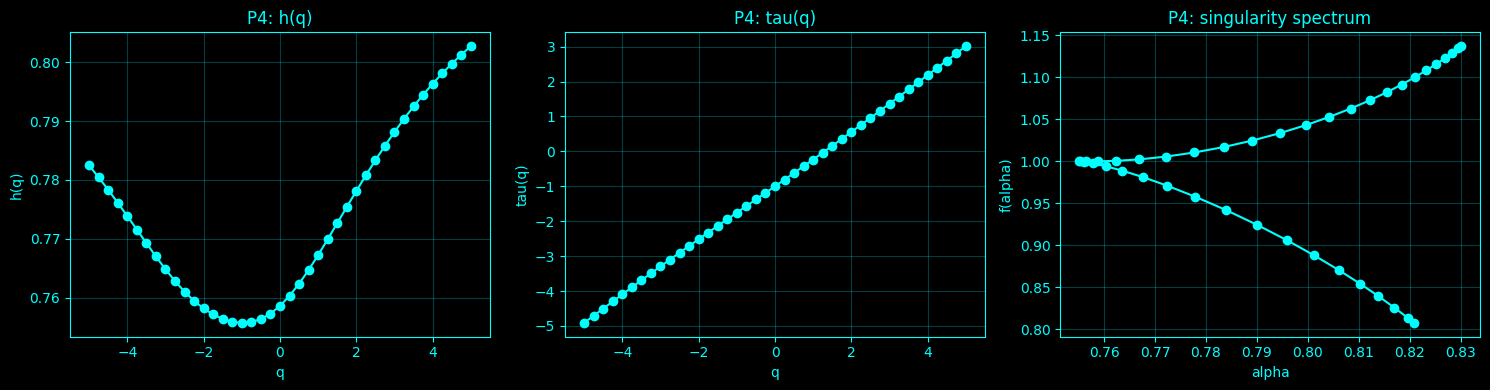

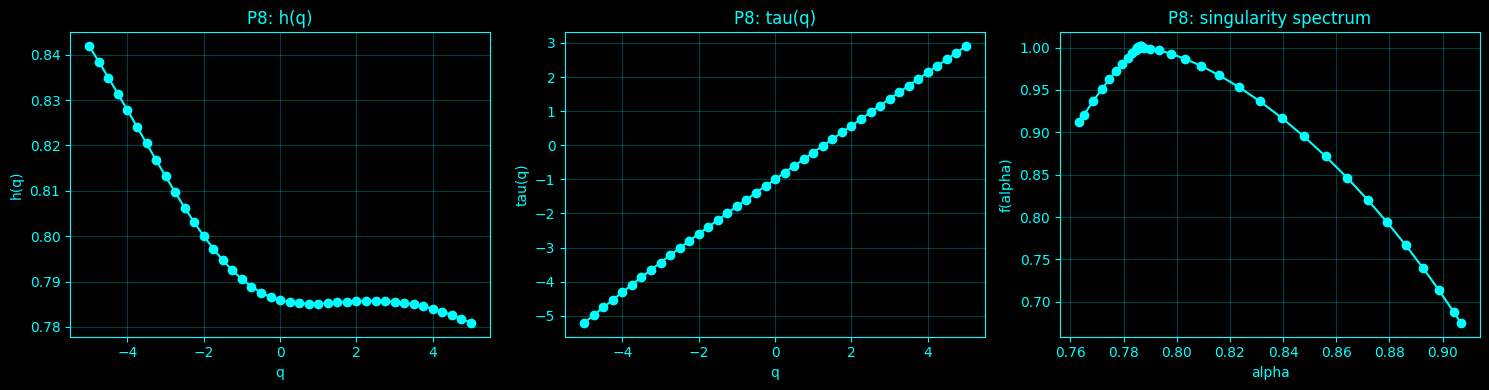

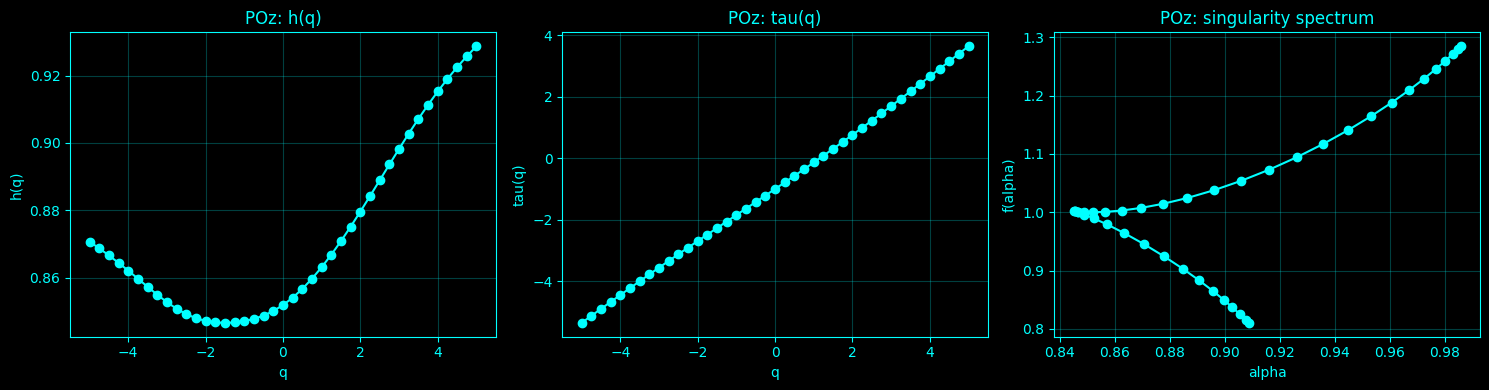

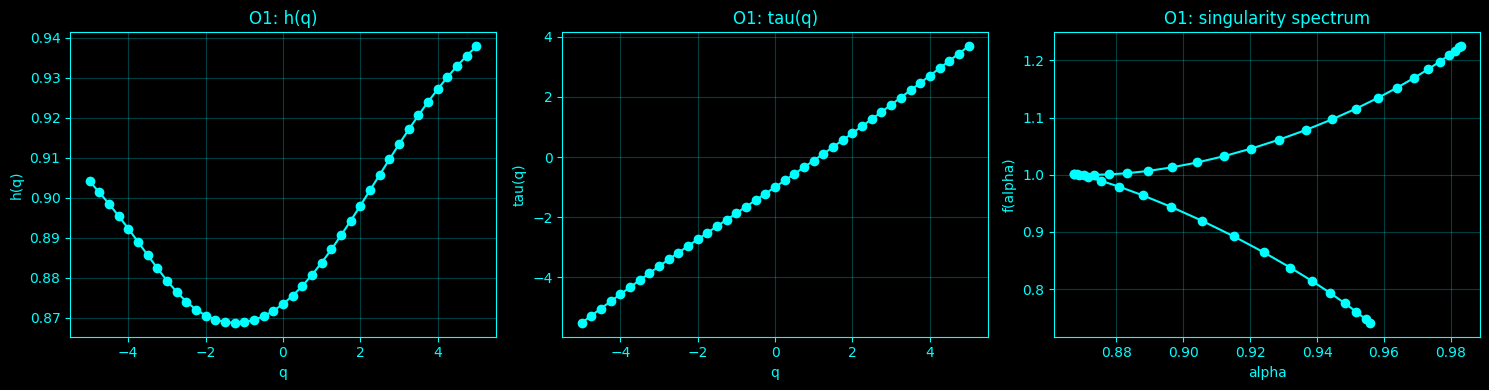

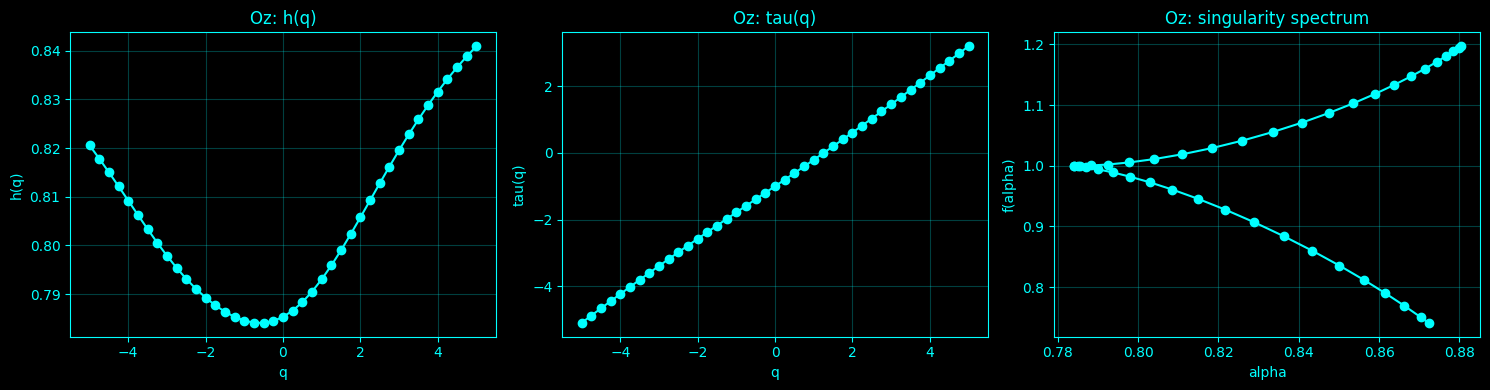

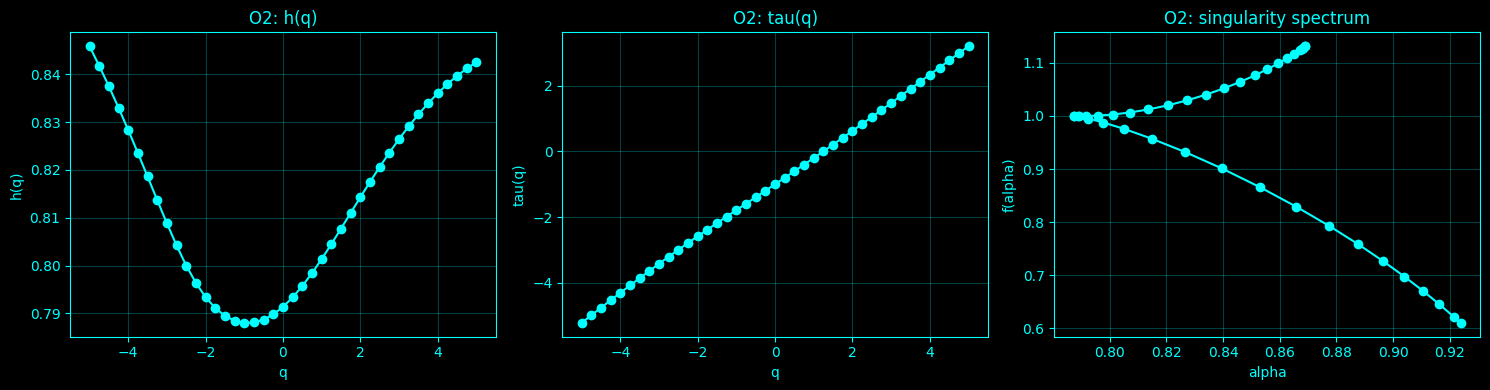


Summary table:
   channel  alpha_min  alpha_max  alpha_width  alpha_at_peak    f_peak  \
0      Fp1   0.928410   1.081400     0.152990       1.081400  1.089866   
1      Fpz   0.941263   1.077939     0.136676       1.077939  1.090701   
2      Fp2   0.922671   1.068931     0.146259       1.068931  1.086196   
3       F7   0.808386   0.879728     0.071342       0.879728  1.089354   
4       F3   0.813601   0.884761     0.071160       0.884610  1.121409   
5       Fz   0.856922   0.960124     0.103202       0.960124  1.170697   
6       F4   0.854307   0.967664     0.113358       0.946370  1.185287   
7       F8   0.843007   0.917111     0.074105       0.887478  1.087259   
8      FC5   0.760156   0.838955     0.078799       0.789056  1.065045   
9      FC1   0.791435   0.907689     0.116254       0.874228  1.166935   
10     FC2   0.815470   0.907625     0.092155       0.907625  1.210091   
11     FC6   0.812244   0.942932     0.130688       0.870570  1.112902   
12      M1   0.865558 

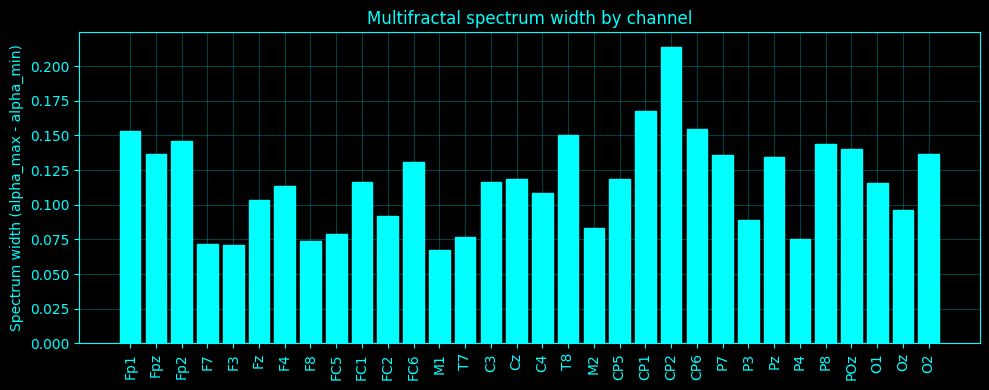


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_manual_spectrum_results
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_manual_spectrum_results/mfdfa_manual_spectrum_summary.csv


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_manual_spectrum_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1  # DFA-1

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    """
    Manual MFDFA.
    Returns:
        scales_out, Fq   where Fq.shape = (n_scales, n_q)
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    # Profile
    profile = np.cumsum(x - np.mean(x))

    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # Forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        # Backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    """
    Fit log Fq(s) vs log s for each q.
    Returns h(q).
    """
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    """
    tau(q)   = q*h(q) - 1
    alpha(q) = d tau / d q
    f(alpha) = q*alpha - tau
    """
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# Keep only valid scales for this segment length
lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN CHANNELS
# -------------------------------------------------------
summary_rows = []

for ch in range(num_channels):
    channel_name = eeg_channels[ch]
    x = EEG_segment[:, ch].astype(float)

    # MFDFA
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)

    # Spectrum
    spec = compute_multifractal_spectrum(q_vals, hq)
    tau = spec["tau"]
    alpha = spec["alpha"]
    f_alpha = spec["f_alpha"]

    summary = summarize_spectrum(alpha, f_alpha)

    # Save per-channel numerical results
    npz_path = os.path.join(out_dir, f"{channel_name}_mfdfa_manual_spectrum.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        scales=scales_out,
        q_vals=q_vals,
        Fq=Fq,
        hq=hq,
        tau=tau,
        alpha=alpha,
        f_alpha=f_alpha,
        alpha_min=summary["alpha_min"],
        alpha_max=summary["alpha_max"],
        alpha_width=summary["alpha_width"],
        alpha_at_peak=summary["alpha_at_peak"],
        f_peak=summary["f_peak"],
        asymmetry=summary["asymmetry"],
    )

    summary_rows.append({
        "channel": channel_name,
        "alpha_min": summary["alpha_min"],
        "alpha_max": summary["alpha_max"],
        "alpha_width": summary["alpha_width"],
        "alpha_at_peak": summary["alpha_at_peak"],
        "f_peak": summary["f_peak"],
        "asymmetry": summary["asymmetry"],
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

    for ax in axes:
        style_ax(ax)

    axes[0].plot(
        q_vals, hq,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    axes[1].plot(
        q_vals, tau,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: tau(q)")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")

    mask = np.isfinite(alpha) & np.isfinite(f_alpha)
    axes[2].plot(
        alpha[mask], f_alpha[mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[2].set_title(f"{channel_name}: singularity spectrum")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")

    plt.tight_layout()

    fig_path = os.path.join(out_dir, f"{channel_name}_mfdfa_spectrum.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
mf_summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "mfdfa_manual_spectrum_summary.csv")
mf_summary_df.to_csv(summary_csv, index=False)

print("\nSummary table:")
print(mf_summary_df)

# -------------------------------------------------------
# COMPARE SPECTRUM WIDTH ACROSS CHANNELS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)
ax.bar(
    mf_summary_df["channel"],
    mf_summary_df["alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_ylabel("Spectrum width (alpha_max - alpha_min)")
ax.set_title("Multifractal spectrum width by channel")
ax.tick_params(axis='x', rotation=90, colors=ACCENT)

plt.tight_layout()
bar_path = os.path.join(out_dir, "mfdfa_spectrum_width_by_channel.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


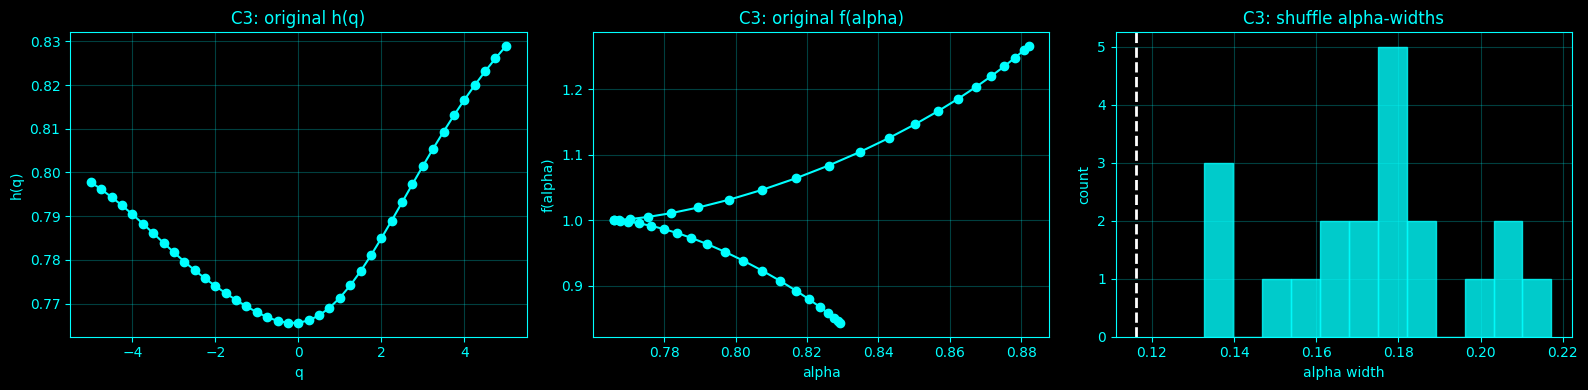


Shuffle-comparison summary:
  channel  alpha_width_original  alpha_width_shuffle_mean  \
0      C3              0.116223                  0.173852   

   alpha_width_shuffle_std  delta_width  p_upper_shuffle_ge_original  \
0                 0.024122    -0.057629                          1.0   

   alpha_min_original  alpha_max_original  alpha_at_peak_original  \
0            0.765867             0.88209                 0.88209   

   f_peak_original  asymmetry_original  
0         1.265926           -0.116223  


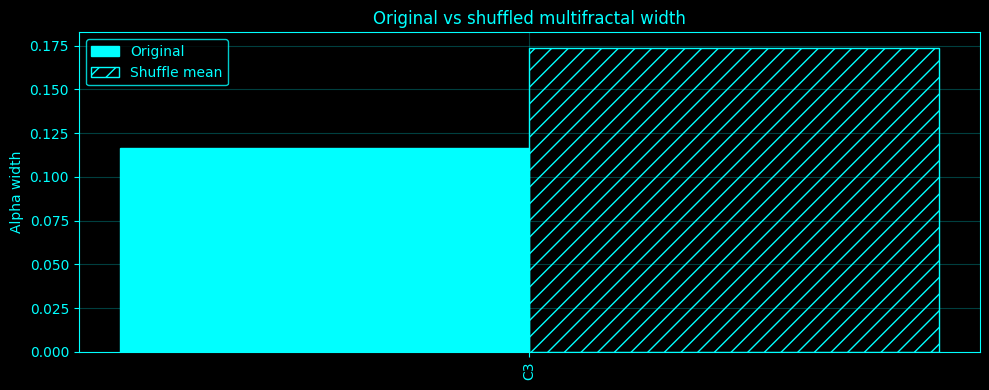


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_shuffle_surrogate_results
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_shuffle_surrogate_results/shuffle_mfdfa_summary.csv


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_shuffle_surrogate_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Start with C3; change to eeg_channels to run all channels
channels_to_run = ["C3"]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1

# Shuffle surrogates
n_shuffles = 20
seed = 0

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_width(x, scales, q_vals, order=1):
    scales_out, Fq = mfdfa_manual(x, scales, q_vals, order=order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}
rng = np.random.default_rng(seed)

# -------------------------------------------------------
# RUN ORIGINAL VS SHUFFLED
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Original
    original = run_mfdfa_width(x, lag, q_vals, order=poly_order)
    orig_width = original["alpha_width"]

    # Shuffles
    shuffle_widths = []
    for s in range(n_shuffles):
        xs = rng.permutation(x)
        shuffled = run_mfdfa_width(xs, lag, q_vals, order=poly_order)
        shuffle_widths.append(shuffled["alpha_width"])

    shuffle_widths = np.asarray(shuffle_widths, dtype=float)

    shuffle_mean = np.nanmean(shuffle_widths)
    shuffle_std = np.nanstd(shuffle_widths, ddof=1) if np.sum(np.isfinite(shuffle_widths)) > 1 else np.nan

    # one-sided empirical p-value: how often shuffled width >= original width
    p_upper = (np.sum(shuffle_widths >= orig_width) + 1.0) / (len(shuffle_widths) + 1.0)

    summary_rows.append({
        "channel": channel_name,
        "alpha_width_original": orig_width,
        "alpha_width_shuffle_mean": shuffle_mean,
        "alpha_width_shuffle_std": shuffle_std,
        "delta_width": orig_width - shuffle_mean,
        "p_upper_shuffle_ge_original": p_upper,
        "alpha_min_original": original["alpha_min"],
        "alpha_max_original": original["alpha_max"],
        "alpha_at_peak_original": original["alpha_at_peak"],
        "f_peak_original": original["f_peak"],
        "asymmetry_original": original["asymmetry"],
    })

    # Save detailed NPZ
    npz_path = os.path.join(out_dir, f"{channel_name}_shuffle_mfdfa_comparison.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        q_vals=q_vals,
        scales=original["scales"],
        hq_original=original["hq"],
        tau_original=original["tau"],
        alpha_original=original["alpha"],
        f_alpha_original=original["f_alpha"],
        alpha_width_original=orig_width,
        shuffle_widths=shuffle_widths,
        alpha_width_shuffle_mean=shuffle_mean,
        alpha_width_shuffle_std=shuffle_std,
        p_upper_shuffle_ge_original=p_upper,
        n_shuffles=n_shuffles,
        seed=seed,
    )

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    # h(q)
    axes[0].plot(
        q_vals, original["hq"],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: original h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    # original singularity spectrum
    mask = np.isfinite(original["alpha"]) & np.isfinite(original["f_alpha"])
    axes[1].plot(
        original["alpha"][mask], original["f_alpha"][mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: original f(alpha)")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel("f(alpha)")

    # shuffle histogram
    axes[2].hist(shuffle_widths[np.isfinite(shuffle_widths)], bins=12, color=ACCENT, edgecolor=ACCENT, alpha=0.8)
    axes[2].axvline(orig_width, color="white", linestyle="--", linewidth=2)
    axes[2].set_title(f"{channel_name}: shuffle alpha-widths")
    axes[2].set_xlabel("alpha width")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_shuffle_mfdfa_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "shuffle_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nShuffle-comparison summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY BAR PLOT
# -------------------------------------------------------
if len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    xloc = np.arange(len(summary_df))
    width = 0.38

    ax.bar(
        xloc - width/2,
        summary_df["alpha_width_original"],
        width=width,
        color=ACCENT,
        edgecolor=ACCENT,
        label="Original"
    )
    ax.bar(
        xloc + width/2,
        summary_df["alpha_width_shuffle_mean"],
        width=width,
        color="none",
        edgecolor=ACCENT,
        hatch="//",
        label="Shuffle mean"
    )

    ax.set_xticks(xloc)
    ax.set_xticklabels(summary_df["channel"], rotation=90)
    ax.set_ylabel("Alpha width")
    ax.set_title("Original vs shuffled multifractal width")
    ax.legend()

    plt.tight_layout()
    summary_plot = os.path.join(out_dir, "shuffle_mfdfa_summary_plot.png")
    plt.savefig(summary_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


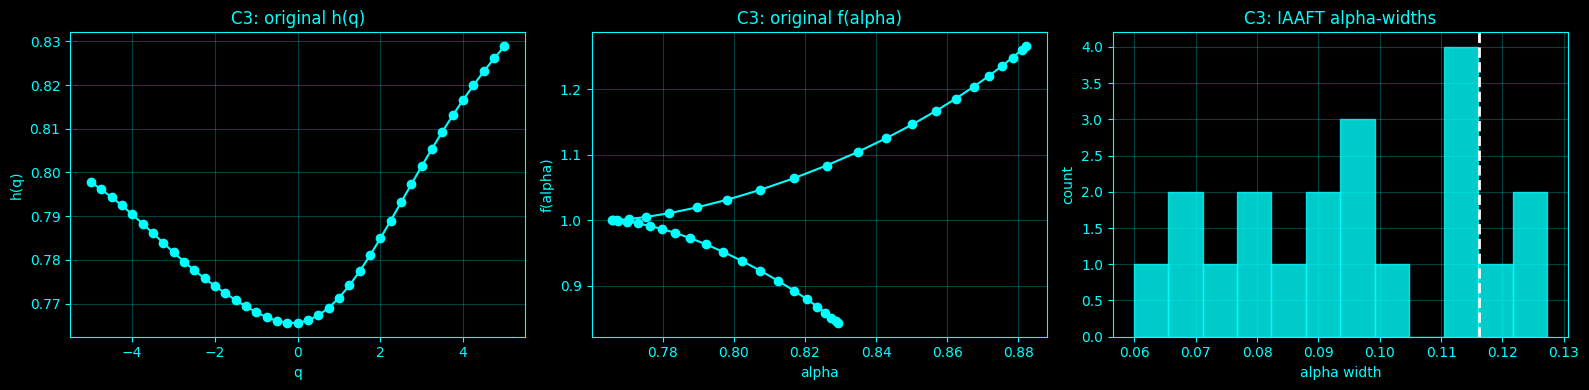


IAAFT-comparison summary:
  channel  alpha_width_original  alpha_width_iaaft_mean  \
0      C3              0.116223                0.095414   

   alpha_width_iaaft_std  delta_width  p_upper_iaaft_ge_original  \
0               0.020005     0.020809                   0.190476   

   alpha_min_original  alpha_max_original  alpha_at_peak_original  \
0            0.765867             0.88209                 0.88209   

   f_peak_original  asymmetry_original  
0         1.265926           -0.116223  

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_iaaft_surrogate_results
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_iaaft_surrogate_results/iaaft_mfdfa_summary.csv


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_iaaft_surrogate_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Start with C3
channels_to_run = ["C3"]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1

# IAAFT surrogate settings
n_surrogates = 20
iaaft_iters = 200
seed = 0

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_width(x, scales, q_vals, order=1):
    scales_out, Fq = mfdfa_manual(x, scales, q_vals, order=order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = np.asarray(x, dtype=float)
    N = len(x)

    x_sorted = np.sort(x)
    X = np.fft.rfft(x)
    target_mag = np.abs(X)

    y = rng.permutation(x)

    for _ in range(n_iter):
        # enforce spectrum
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)

        # enforce amplitude distribution
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2

    return y

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}
rng = np.random.default_rng(seed)

# -------------------------------------------------------
# RUN ORIGINAL VS IAAFT SURROGATES
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Original
    original = run_mfdfa_width(x, lag, q_vals, order=poly_order)
    orig_width = original["alpha_width"]

    # IAAFT surrogates
    surrogate_widths = []
    for s in range(n_surrogates):
        xs = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
        sur = run_mfdfa_width(xs, lag, q_vals, order=poly_order)
        surrogate_widths.append(sur["alpha_width"])

    surrogate_widths = np.asarray(surrogate_widths, dtype=float)

    surr_mean = np.nanmean(surrogate_widths)
    surr_std = np.nanstd(surrogate_widths, ddof=1) if np.sum(np.isfinite(surrogate_widths)) > 1 else np.nan

    # one-sided empirical p-value: how often surrogate width >= original width
    p_upper = (np.sum(surrogate_widths >= orig_width) + 1.0) / (len(surrogate_widths) + 1.0)

    summary_rows.append({
        "channel": channel_name,
        "alpha_width_original": orig_width,
        "alpha_width_iaaft_mean": surr_mean,
        "alpha_width_iaaft_std": surr_std,
        "delta_width": orig_width - surr_mean,
        "p_upper_iaaft_ge_original": p_upper,
        "alpha_min_original": original["alpha_min"],
        "alpha_max_original": original["alpha_max"],
        "alpha_at_peak_original": original["alpha_at_peak"],
        "f_peak_original": original["f_peak"],
        "asymmetry_original": original["asymmetry"],
    })

    # Save detailed NPZ
    npz_path = os.path.join(out_dir, f"{channel_name}_iaaft_mfdfa_comparison.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        q_vals=q_vals,
        scales=original["scales"],
        hq_original=original["hq"],
        tau_original=original["tau"],
        alpha_original=original["alpha"],
        f_alpha_original=original["f_alpha"],
        alpha_width_original=orig_width,
        iaaft_widths=surrogate_widths,
        alpha_width_iaaft_mean=surr_mean,
        alpha_width_iaaft_std=surr_std,
        p_upper_iaaft_ge_original=p_upper,
        n_surrogates=n_surrogates,
        iaaft_iters=iaaft_iters,
        seed=seed,
    )

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    axes[0].plot(
        q_vals, original["hq"],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: original h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    mask = np.isfinite(original["alpha"]) & np.isfinite(original["f_alpha"])
    axes[1].plot(
        original["alpha"][mask], original["f_alpha"][mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: original f(alpha)")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel("f(alpha)")

    axes[2].hist(
        surrogate_widths[np.isfinite(surrogate_widths)],
        bins=12,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8
    )
    axes[2].axvline(orig_width, color="white", linestyle="--", linewidth=2)
    axes[2].set_title(f"{channel_name}: IAAFT alpha-widths")
    axes[2].set_xlabel("alpha width")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_iaaft_mfdfa_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "iaaft_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nIAAFT-comparison summary:")
print(summary_df)

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec

Wavelet-leader summary:
   channel  trimmed_length  alpha_min  alpha_max  alpha_width  alpha_at_peak  \
0      Fp1           65536  -0.434384   1.363719     1.798103       0.651677   
1      Fpz           65536  -0.453587   1.408792     1.862378       0.641687   
2      Fp2           65536  -0.444275   1.393668     1.837943       0.660607   
3       F7           65536  -0.296761   0.893227     1.189988       0.318717   
4       F3           65536  -0.281820   0.852748     1.134568       0.352911   
5       Fz           65536  -0.345037   1.052281     1.397318       0.462193   
6       F4           65536  -0.326768   0.990632     1.317399       0.413877   
7       F8           65536  -0.319988   0.962529     1.282517       0.344755   
8      FC5           65536  -0.240557   0.719788     0.960346       0.237556   
9      FC1           65536  -0.249217   0.752145     1.001362       0.297932   
10     FC2    

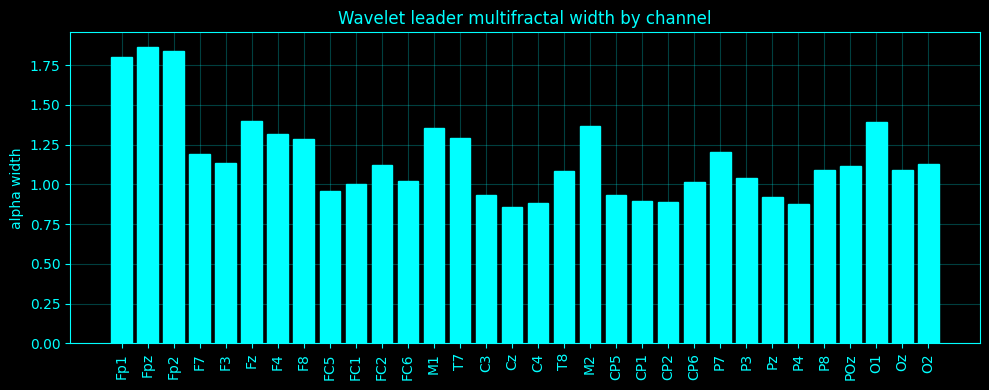


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/wavelet_leader_manual_results
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/wavelet_leader_manual_results/wavelet_leader_summary.csv


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "wavelet_leader_manual_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Analyze all channels by default
channels_to_run = eeg_channels.copy()

# q-grid for multifractal scaling
q_vals = np.linspace(-4, 4, 33)

# Fit-scale controls
# We fit zeta(q) vs dyadic scale exponent j
# using only intermediate scales.
fit_j_min = 2
min_leaders_per_scale = 16

# Optional hard cap on maximum level used in the fit
# Set to None to auto-use all valid scales
fit_j_max = None

# Numerical floor
eps = 1e-12

# Plot style
ACCENT = "cyan"
BG = "black"

# Save per-channel plots; set False if you only want summary
save_per_channel_plots = True
show_per_channel_plots = False

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def trim_to_power_of_two(x):
    """
    Trim to the largest power-of-two length for exact dyadic Haar decomposition.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    J = int(np.floor(np.log2(N)))
    N2 = 2 ** J
    return x[:N2], J

def haar_multilevel_details(x):
    """
    Manual orthonormal Haar decomposition.

    Returns
    -------
    x_use : trimmed signal
    details : list of detail coefficient arrays
        details[j-1] corresponds to dyadic level j
        where j=1 is the finest scale.
    approx_last : coarsest approximation
    """
    x_use, J = trim_to_power_of_two(x)
    approx = x_use.copy()
    details = []

    for _ in range(J):
        n = len(approx) // 2
        a = (approx[0:2*n:2] + approx[1:2*n:2]) / np.sqrt(2.0)
        d = (approx[0:2*n:2] - approx[1:2*n:2]) / np.sqrt(2.0)
        details.append(d)
        approx = a

    return x_use, details, approx

def compute_wavelet_leaders(details, eps=1e-12):
    """
    Manual 1D wavelet leaders from Haar detail coefficients.

    For each dyadic interval lambda_{j,k}, define the leader as the supremum
    of |d_{j',k'}| over all finer/equal scales j' <= j whose support intersects
    the 3-neighborhood of lambda_{j,k}.

    Here:
      - details[j-1] is level j
      - j=1 is finest
      - interval length at level j is 2^j samples
    """
    J = len(details)
    leaders = []

    for j in range(1, J + 1):
        coeffs_j = details[j - 1]
        n_blocks = len(coeffs_j)
        L_j = np.full(n_blocks, eps, dtype=float)

        block_len_j = 2 ** j

        for k in range(n_blocks):
            # 3-neighborhood of lambda_{j,k}
            # lambda_{j,k} spans [k*2^j, (k+1)*2^j - 1]
            # 3lambda spans [(k-1)*2^j, (k+2)*2^j - 1]
            start = (k - 1) * block_len_j
            end   = (k + 2) * block_len_j - 1

            max_val = eps

            # include all finer/equal scales jp <= j
            for jp in range(1, j + 1):
                coeffs_jp = details[jp - 1]
                block_len_jp = 2 ** jp

                kp_min = int(np.floor(start / block_len_jp))
                kp_max = int(np.floor(end   / block_len_jp))

                kp_min = max(0, kp_min)
                kp_max = min(len(coeffs_jp) - 1, kp_max)

                if kp_min <= kp_max:
                    local_max = np.max(np.abs(coeffs_jp[kp_min:kp_max + 1]))
                    if local_max > max_val:
                        max_val = local_max

            L_j[k] = max(max_val, eps)

        leaders.append(L_j)

    return leaders

def leader_structure_functions(leaders, q_vals, eps=1e-12):
    """
    Compute leader-based structure functions:
        S(q,j) = mean( L_{j,k}^q )

    For q=0, use the geometric mean:
        S(0,j) = exp(mean(log L_{j,k}))
    """
    J = len(leaders)
    S = np.full((J, len(q_vals)), np.nan, dtype=float)

    for j in range(J):
        Lj = np.asarray(leaders[j], dtype=float)
        Lj = np.maximum(Lj, eps)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                S[j, qi] = np.exp(np.mean(np.log(Lj)))
            else:
                S[j, qi] = np.mean(Lj ** q)

    return S

def estimate_zeta_from_leaders(scale_exponents, S_qj, q_vals, fit_j_min=2, fit_j_max=None, min_leaders_per_scale=16, leaders=None):
    """
    Estimate zeta(q) from:
        S(q,j) ~ 2^{ j * zeta(q) }

    Since log2(scale) = j, fitting log2 S(q,j) vs j gives zeta(q).

    We only fit scales that:
      - satisfy j >= fit_j_min
      - satisfy j <= fit_j_max (if given)
      - have enough leader coefficients
    """
    zeta = np.full(len(q_vals), np.nan, dtype=float)

    valid_scale_mask = np.ones_like(scale_exponents, dtype=bool)
    valid_scale_mask &= (scale_exponents >= fit_j_min)

    if fit_j_max is not None:
        valid_scale_mask &= (scale_exponents <= fit_j_max)

    if leaders is not None:
        counts = np.array([len(L) for L in leaders], dtype=int)
        valid_scale_mask &= (counts >= min_leaders_per_scale)

    for qi in range(len(q_vals)):
        y = S_qj[:, qi]
        mask = valid_scale_mask & np.isfinite(y) & (y > 0)

        if np.sum(mask) >= 4:
            xfit = scale_exponents[mask]
            yfit = np.log2(y[mask])
            coef = np.polyfit(xfit, yfit, 1)
            zeta[qi] = coef[0]

    return zeta, valid_scale_mask

def legendre_singularity_spectrum(q_vals, zeta):
    """
    Legendre transform in dimension d=1:
        alpha(q) = d zeta / d q
        f(alpha) = q*alpha - zeta(q) + 1
    """
    q_vals = np.asarray(q_vals, dtype=float)
    zeta = np.asarray(zeta, dtype=float)

    alpha = np.full_like(zeta, np.nan, dtype=float)
    f_alpha = np.full_like(zeta, np.nan, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(zeta)
    if np.sum(valid) >= 5:
        qv = q_vals[valid]
        zv = zeta[valid]
        av = np.gradient(zv, qv)
        fv = qv * av - zv + 1.0

        alpha[valid] = av
        f_alpha[valid] = fv

    return alpha, f_alpha

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG FROM PATH, SAME SEGMENT AS BEFORE
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN ALL REQUESTED CHANNELS
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Manual Haar multiresolution analysis
    x_use, details, approx_last = haar_multilevel_details(x)

    # Manual leaders
    leaders = compute_wavelet_leaders(details, eps=eps)

    # Structure functions
    S_qj = leader_structure_functions(leaders, q_vals, eps=eps)

    # Dyadic scale exponent j = 1,2,...,J
    J = len(leaders)
    scale_exponents = np.arange(1, J + 1)

    # Estimate zeta(q)
    zeta, fit_mask = estimate_zeta_from_leaders(
        scale_exponents,
        S_qj,
        q_vals,
        fit_j_min=fit_j_min,
        fit_j_max=fit_j_max,
        min_leaders_per_scale=min_leaders_per_scale,
        leaders=leaders
    )

    # Singularity spectrum
    alpha, f_alpha = legendre_singularity_spectrum(q_vals, zeta)

    # Summary
    summary = summarize_spectrum(alpha, f_alpha)

    # Save per-channel arrays
    npz_path = os.path.join(out_dir, f"{channel_name}_wavelet_leader_manual.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        trimmed_length=len(x_use),
        scale_exponents=scale_exponents,
        q_vals=q_vals,
        zeta=zeta,
        alpha=alpha,
        f_alpha=f_alpha,
        fit_mask=fit_mask,
        alpha_min=summary["alpha_min"],
        alpha_max=summary["alpha_max"],
        alpha_width=summary["alpha_width"],
        alpha_at_peak=summary["alpha_at_peak"],
        f_peak=summary["f_peak"],
        asymmetry=summary["asymmetry"],
    )

    summary_rows.append({
        "channel": channel_name,
        "trimmed_length": len(x_use),
        "alpha_min": summary["alpha_min"],
        "alpha_max": summary["alpha_max"],
        "alpha_width": summary["alpha_width"],
        "alpha_at_peak": summary["alpha_at_peak"],
        "f_peak": summary["f_peak"],
        "asymmetry": summary["asymmetry"],
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

    for ax in axes:
        style_ax(ax)

    # zeta(q)
    axes[0].plot(
        q_vals, zeta,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: zeta(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("zeta(q)")

    # alpha(q)
    axes[1].plot(
        q_vals, alpha,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: alpha(q)")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("alpha(q)")

    # f(alpha)
    mask = np.isfinite(alpha) & np.isfinite(f_alpha)
    axes[2].plot(
        alpha[mask], f_alpha[mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[2].set_title(f"{channel_name}: wavelet leader spectrum")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")

    plt.tight_layout()

    if save_per_channel_plots:
        fig_path = os.path.join(out_dir, f"{channel_name}_wavelet_leader_spectrum.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")

    if show_per_channel_plots:
        plt.show()

    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "wavelet_leader_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nWavelet-leader summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY BAR PLOT
# -------------------------------------------------------
if len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    ax.bar(
        summary_df["channel"],
        summary_df["alpha_width"],
        color=ACCENT,
        edgecolor=ACCENT
    )
    ax.set_ylabel("alpha width")
    ax.set_title("Wavelet leader multifractal width by channel")
    ax.tick_params(axis='x', rotation=90, colors=ACCENT)

    plt.tight_layout()
    summary_plot = os.path.join(out_dir, "wavelet_leader_width_by_channel.png")
    plt.savefig(summary_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")